In [ ]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Analise\ de\ dados

events = pd.read_csv("events.csv")
display (events)


Mounted at /content/drive
/content/drive/MyDrive/Analise de dados


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


In [ ]:
countries = pd.read_csv("countries.csv")
display (countries)

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia
...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,Oceania,Polynesia
245,Western Sahara,EH,ESH,Africa,Northern Africa
246,Yemen,YE,YEM,Asia,Western Asia
247,Zambia,ZM,ZMB,Africa,Sub-Saharan Africa


In [ ]:
products = pd.read_csv("products.csv")
display (products)

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


## Data Overview: `events` DataFrame

In [ ]:
print("Info for events DataFrame:")
events.info()
print("\nDescription for events DataFrame:")
display(events.describe(include='all'))
print("\nFirst 5 rows of events DataFrame:")
display(events.head())

Info for events DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

Description for events DataFrame:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330,1330,1330,1248,1330.000000,1330,1328.000000,1330.000000,1330.000000
unique,NaN,1049,1070,6,45,NaN,3,NaN,NaN,NaN
top,NaN,6/10/2011,6/1/2013,M,SMR,NaN,Offline,NaN,NaN,NaN
freq,NaN,4,3,353,40,NaN,667,NaN,NaN,NaN
mean,5.412048e+08,NaN,NaN,NaN,NaN,5788.096241,NaN,4952.201807,264.893541,187.246812
std,2.573882e+08,NaN,NaN,NaN,NaN,2820.728878,NaN,2905.198996,217.323460,176.158873
min,1.006406e+08,NaN,NaN,NaN,NaN,1270.000000,NaN,2.000000,9.330000,6.920000
25%,3.190004e+08,NaN,NaN,NaN,NaN,3127.000000,NaN,2356.750000,81.730000,35.840000
50%,5.387164e+08,NaN,NaN,NaN,NaN,5988.000000,NaN,4962.000000,154.060000,97.440000
75%,7.544628e+08,NaN,NaN,NaN,NaN,8681.000000,NaN,7459.500000,437.200000,263.330000



First 5 rows of events DataFrame:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
print("Info for countries DataFrame:")
countries.info()
print("\nDescription for countries DataFrame:")
display(countries.describe(include='all'))
print("\nFirst 5 rows of countries DataFrame:")
display(countries.head())

Info for countries DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB

Description for countries DataFrame:


,name,alpha-2,alpha-3,region,sub-region
count,249,248,249,248,248
unique,249,248,249,5,17
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53



First 5 rows of countries DataFrame:


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


## Data Overview: `products` DataFrame

In [ ]:
print("Info for products DataFrame:")
products.info()
print("\nDescription for products DataFrame:")
display(products.describe(include='all'))
print("\nFirst 5 rows of products DataFrame:")
display(products.head())

Info for products DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes

Description for products DataFrame:


,id,item_type
count,12.000000,12
unique,NaN,12
top,NaN,Cereal
freq,NaN,1
mean,5802.166667,NaN
std,2937.985452,NaN
min,1270.000000,NaN
25%,2959.000000,NaN
50%,6659.500000,NaN
75%,8390.000000,NaN



First 5 rows of products DataFrame:


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


### Campos Chave para Junção de Tabelas

Com base nos nomes das colunas e no contexto dos dados, aqui estão os potenciais campos chave para conectar as três tabelas:

*   **`events` e `countries`**: O DataFrame `events` possui uma coluna `Country Code`, que provavelmente corresponde às colunas `alpha-2` ou `alpha-3` no DataFrame `countries`. Precisaremos verificar isso durante a limpeza dos dados.
*   **`events` e `products`**: O DataFrame `events` possui uma coluna `Item ID`, que provavelmente corresponde à coluna `id` no DataFrame `products`.

## Passo 2: Pré-processamento e Limpeza de Dados

### 2.1 Tratamento de Valores Ausentes

Vamos identificar a proporção de valores ausentes em cada DataFrame e decidir sobre a melhor estratégia para tratá-los.

In [ ]:
print("Valores ausentes no DataFrame 'events':")
display(events.isnull().sum())
print("\nProporção de valores ausentes no DataFrame 'events':")
display(events.isnull().sum() / len(events) * 100)

Valores ausentes no DataFrame 'events':


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0



Proporção de valores ausentes no DataFrame 'events':


,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


#### Tratamento de Valores Ausentes no DataFrame `events`

As colunas `Country Code` e `Units Sold` possuem valores ausentes. A coluna `Country Code` tem aproximadamente 6.17% de valores ausentes, enquanto `Units Sold` tem uma proporção muito pequena 0.15%.

*   Para `Units Sold`, a baixa proporção permite a remoção das linhas afetadas ou a imputação pela média/mediana. Para manter a integridade dos dados e evitar distorções, optaremos por remover as 2 linhas com valores ausentes.
*   Para `Country Code`, 6.17% ainda é uma proporção significativa para simplesmente remover. No entanto, sem informações adicionais para imputar, a remoção pode ser a opção mais segura para análises que dependem desse campo. Vamos remover as linhas por enquanto. Se houver necessidade futura, podemos revisitar a imputação.


In [ ]:
# Removendo linhas com valores ausentes em 'Country Code' e 'Units Sold'
events.dropna(subset=['Country Code', 'Units Sold'], inplace=True)

print("Valores ausentes no DataFrame 'events' após o tratamento:")
display(events.isnull().sum())
print("\nTamanho do DataFrame 'events' após o tratamento de valores ausentes:", len(events))

Valores ausentes no DataFrame 'events' após o tratamento:


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0



Tamanho do DataFrame 'events' após o tratamento de valores ausentes: 1246


In [ ]:
print("Valores ausentes no DataFrame 'countries':")
display(countries.isnull().sum())
print("\nProporção de valores ausentes no DataFrame 'countries':")
display(countries.isnull().sum() / len(countries) * 100)

Valores ausentes no DataFrame 'countries':


,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1



Proporção de valores ausentes no DataFrame 'countries':


,0
name,0.000000
alpha-2,0.401606
alpha-3,0.000000
region,0.401606
sub-region,0.401606


#### Tratamento de Valores Ausentes no DataFrame `countries`

As colunas `alpha-2`, `region` e `sub-region` possuem apenas 1 valor ausente cada. A remoção da linha afetada é uma abordagem razoável, dada a pequena proporção e a natureza dos dados (informações geográficas).

In [ ]:
# Removendo linhas com valores ausentes no DataFrame 'countries'
countries.dropna(inplace=True)

print("Valores ausentes no DataFrame 'countries' após o tratamento:")
display(countries.isnull().sum())
print("\nTamanho do DataFrame 'countries' após o tratamento de valores ausentes:", len(countries))

Valores ausentes no DataFrame 'countries' após o tratamento:


,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0



Tamanho do DataFrame 'countries' após o tratamento de valores ausentes: 247


In [ ]:
print("Valores ausentes no DataFrame 'products':")
display(products.isnull().sum())

Valores ausentes no DataFrame 'products':


,0
id,0
item_type,0


In [ ]:
# Convertendo 'Order Date' e 'Ship Date' para datetime no DataFrame 'events'
events['Order Date'] = pd.to_datetime(events['Order Date'])
events['Ship Date'] = pd.to_datetime(events['Ship Date'])

print("Tipos de dados do DataFrame 'events' após a conversão de datas:")
events.info()

print("\nTipos de dados do DataFrame 'countries':")
countries.info()

print("\nTipos de dados do DataFrame 'products':")
products.info()

Tipos de dados do DataFrame 'events' após a conversão de datas:
<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 107.1+ KB

Tipos de dados do DataFrame 'countries':
<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 0 to 248
Data columns (tota

In [ ]:
print("Número de linhas duplicadas no DataFrame 'events':", events.duplicated().sum())
# Removendo duplicatas em 'events', se houver
events.drop_duplicates(inplace=True)
print("Tamanho do DataFrame 'events' após remover duplicatas:", len(events))

print("\nNúmero de linhas duplicadas no DataFrame 'countries':", countries.duplicated().sum())
# Removendo duplicatas em 'countries', se houver
countries.drop_duplicates(inplace=True)
print("Tamanho do DataFrame 'countries' após remover duplicatas:", len(countries))

print("\nNúmero de linhas duplicadas no DataFrame 'products':", products.duplicated().sum())
# Removendo duplicatas em 'products', se houver
products.drop_duplicates(inplace=True)
print("Tamanho do DataFrame 'products' após remover duplicatas:", len(products))

Número de linhas duplicadas no DataFrame 'events': 0
Tamanho do DataFrame 'events' após remover duplicatas: 1246

Número de linhas duplicadas no DataFrame 'countries': 0
Tamanho do DataFrame 'countries' após remover duplicatas: 247

Número de linhas duplicadas no DataFrame 'products': 0
Tamanho do DataFrame 'products' após remover duplicatas: 12


In [ ]:
# Padronizando colunas de string em 'events' para remover espaços extras e converter para minúsculas
for col in ['Order Priority', 'Country Code', 'Sales Channel']:
    if col in events.columns and events[col].dtype == 'object':
        events[col] = events[col].str.strip().str.lower()

# Padronizando colunas de string em 'countries'
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    if col in countries.columns and countries[col].dtype == 'object':
        countries[col] = countries[col].str.strip().str.lower()

# Padronizando colunas de string em 'products'
for col in ['item_type']:
    if col in products.columns and products[col].dtype == 'object':
        products[col] = products[col].str.strip().str.lower()

print("Primeiras linhas do DataFrame 'events' após padronização de strings:")
display(events.head())

print("\nPrimeiras linhas do DataFrame 'countries' após padronização de strings:")
display(countries.head())

print("\nPrimeiras linhas do DataFrame 'products' após padronização de strings:")
display(products.head())

Primeiras linhas do DataFrame 'events' após padronização de strings:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650.0,205.70,117.11
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993.0,205.70,117.11
3,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171.0,109.28,35.84
4,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648.0,47.45,31.79
5,103450715,2015-03-15,2015-04-18,h,svk,8681,online,2220.0,651.21,524.96



Primeiras linhas do DataFrame 'countries' após padronização de strings:


,name,alpha-2,alpha-3,region,sub-region
0,afghanistan,af,afg,asia,southern asia
1,åland islands,ax,ala,europe,northern europe
2,albania,al,alb,europe,southern europe
3,algeria,dz,dza,africa,northern africa
4,american samoa,as,asm,oceania,polynesia



Primeiras linhas do DataFrame 'products' após padronização de strings:


,id,item_type
0,2103,cereal
1,7940,household
2,2455,clothes
3,1270,beverages
4,8681,office supplies


In [ ]:
# Mesclando events e products
events_products = pd.merge(events, products, left_on='Product ID', right_on='id', how='left')

print("Primeiras 5 linhas do DataFrame 'events_products' após a mesclagem:")
display(events_products.head())

print("Informações do DataFrame 'events_products':")
events_products.info()

Primeiras 5 linhas do DataFrame 'events_products' após a mesclagem:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650.0,205.70,117.11,2103,cereal
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993.0,205.70,117.11,2103,cereal
2,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171.0,109.28,35.84,2455,clothes
3,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648.0,47.45,31.79,1270,beverages
4,103450715,2015-03-15,2015-04-18,h,svk,8681,online,2220.0,651.21,524.96,8681,office supplies


Informações do DataFrame 'events_products':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
 10  id              1246 non-null   int64         
 11  item_type       1246 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(3), object(4)
memory usage: 116.9+ KB


In [ ]:
#Mesclando events_products e countries
df_full = pd.merge(events_products, countries, left_on='Country Code', right_on='alpha-3', how='left')

print("Primeiras 5 linhas do DataFrame final 'df_full' após a mesclagem:")
display(df_full.head())

print("Informações do DataFrame final 'df_full':")
df_full.info()

print("\nVerificando valores ausentes no DataFrame 'df_full' após as mesclagens:")
display(df_full.isnull().sum())

Primeiras 5 linhas do DataFrame final 'df_full' após a mesclagem:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650.0,205.70,117.11,2103,cereal,norway,no,nor,europe,northern europe
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993.0,205.70,117.11,2103,cereal,serbia,rs,srb,europe,southern europe
2,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171.0,109.28,35.84,2455,clothes,montenegro,me,mne,europe,southern europe
3,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648.0,47.45,31.79,1270,beverages,serbia,rs,srb,europe,southern europe
4,103450715,2015-03-15,2015-04-18,h,svk,8681,online,2220.0,651.21,524.96,8681,office supplies,slovakia,sk,svk,europe,eastern europe


Informações do DataFrame final 'df_full':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
 10  id              1246 non-null   int64         
 11  item_type       1246 non-null   object        
 12  name            1246 non-null   object        
 13  alpha-2         1246 non-null   object        
 14  alpha-3       

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
# Removendo colunas redundantes
df_full = df_full.drop(columns=['id', 'alpha-2', 'Product ID', 'Country Code'])

# Renomeando colunas para maior clareza
df_full = df_full.rename(columns={
    'item_type': 'Categoria do Produto',
    'name': 'País',
    'region': 'Região',
    'sub-region': 'Sub-Região',
    'Order Date': 'Data do Pedido',
    'Ship Date': 'Data de Envio',
    'Order Priority': 'Prioridade do Pedido',
    'Sales Channel': 'Canal de Vendas',
    'Units Sold': 'Unidades Vendidas',
    'Unit Price': 'Preço Unitário',
    'Unit Cost': 'Custo Unitário'
})

print("Primeiras 5 linhas do DataFrame `df_full` após remoção e renomeação de colunas:")
display(df_full.head())

print("Informações do DataFrame `df_full` atualizado:")
df_full.info()

Primeiras 5 linhas do DataFrame `df_full` após remoção e renomeação de colunas:


,Order ID,Data do Pedido,Data de Envio,Prioridade do Pedido,Canal de Vendas,Unidades Vendidas,Preço Unitário,Custo Unitário,Categoria do Produto,País,alpha-3,Região,Sub-Região
0,100640618,2014-10-08,2014-10-18,m,online,650.0,205.70,117.11,cereal,norway,nor,europe,northern europe
1,100983083,2016-08-11,2016-08-11,c,offline,1993.0,205.70,117.11,cereal,serbia,srb,europe,southern europe
2,102230632,2017-05-13,2017-06-13,l,online,1171.0,109.28,35.84,clothes,montenegro,mne,europe,southern europe
3,103435266,2012-08-11,2012-09-18,h,offline,7648.0,47.45,31.79,beverages,serbia,srb,europe,southern europe
4,103450715,2015-03-15,2015-04-18,h,online,2220.0,651.21,524.96,office supplies,slovakia,svk,europe,eastern europe


Informações do DataFrame `df_full` atualizado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order ID              1246 non-null   int64         
 1   Data do Pedido        1246 non-null   datetime64[ns]
 2   Data de Envio         1246 non-null   datetime64[ns]
 3   Prioridade do Pedido  1246 non-null   object        
 4   Canal de Vendas       1246 non-null   object        
 5   Unidades Vendidas     1246 non-null   float64       
 6   Preço Unitário        1246 non-null   float64       
 7   Custo Unitário        1246 non-null   float64       
 8   Categoria do Produto  1246 non-null   object        
 9   País                  1246 non-null   object        
 10  alpha-3               1246 non-null   object        
 11  Região                1246 non-null   object        
 12  Sub-Região            1246 no

In [ ]:
# Calculo do lucro unitário e o lucro total
df_full['Lucro Unitário'] = df_full['Preço Unitário'] - df_full['Custo Unitário']
df_full['Lucro Total'] = df_full['Unidades Vendidas'] * df_full['Lucro Unitário']

# Número total de pedidos (baseado em 'Order ID' únicos)
total_pedidos = df_full['Order ID'].nunique()

# Lucro total
lucro_total = df_full['Lucro Total'].sum()

# Número total de países abrangidos
total_paises = df_full['País'].nunique()

# Total de unidades vendidas
total_unidades_vendidas = df_full['Unidades Vendidas'].sum()

# Vendas totais (receita)
vendas_totais = (df_full['Unidades Vendidas'] * df_full['Preço Unitário']).sum()

print(f"Número Total de Pedidos: {total_pedidos}")
print(f"Lucro Total: ${lucro_total:,.2f}")
print(f"Número Total de Países Abangidos: {total_paises}")
print(f"Total de Unidades Vendidas: {total_unidades_vendidas:,.0f}")
print(f"Vendas Totais (Receita): ${vendas_totais:,.2f}")

Número Total de Pedidos: 1246
Lucro Total: $473,709,035.06
Número Total de Países Abangidos: 45
Total de Unidades Vendidas: 6,171,671
Vendas Totais (Receita): $1,598,983,761.26


In [ ]:
# Calculo de Receita e Despesas
df_full['Receita'] = df_full['Unidades Vendidas'] * df_full['Preço Unitário']
df_full['Despesa'] = df_full['Unidades Vendidas'] * df_full['Custo Unitário']

# Análise por Categoria de Produto
analise_categoria = df_full.groupby('Categoria do Produto').agg(
    Total_Receita=('Receita', 'sum'),
    Total_Despesa=('Despesa', 'sum'),
    Total_Lucro=('Lucro Total', 'sum'),
    Unidades_Vendidas=('Unidades Vendidas', 'sum')
).reset_index()

# Calculo da popularidade dos produtos (baseado em unidades vendidas)
analise_categoria['Popularidade'] = analise_categoria['Unidades_Vendidas'] / analise_categoria['Unidades_Vendidas'].sum()

display(analise_categoria.sort_values(by='Total_Lucro', ascending=False))

,Categoria do Produto,Total_Receita,Total_Despesa,Total_Lucro,Unidades_Vendidas,Popularidade
4,cosmetics,2.213054e+08,1.332945e+08,88010907.56,506188.0,0.082018
8,office supplies,3.786662e+08,3.052543e+08,73411976.25,581481.0,0.094218
6,household,2.788744e+08,2.097140e+08,69160454.84,417308.0,0.067617
0,baby food,1.338344e+08,8.357833e+07,50256042.90,524265.0,0.084947
3,clothes,6.330732e+07,2.076258e+07,42544746.72,579313.0,0.093866
2,cereal,9.467672e+07,5.390175e+07,40774964.94,460266.0,0.074577
11,vegetables,8.203849e+07,4.842113e+07,33617356.30,532510.0,0.086283
7,meat,2.013398e+08,1.740421e+08,27297727.60,477233.0,0.077326
10,snacks,6.921349e+07,4.420083e+07,25012661.94,453621.0,0.073501
9,personal care,4.334632e+07,3.005550e+07,13290821.60,530360.0,0.085935


/tmp/ipykernel_4571/1120426643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Total_Lucro', y='Categoria do Produto', data=analise_categoria.sort_values('Total_Lucro', ascending=False), palette='viridis')
/tmp/ipykernel_4571/1120426643.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='Total_Receita', y='Categoria do Produto', data=analise_categoria.sort_values('Total_Receita', ascending=False), palette='magma')
/tmp/ipykernel_4571/1120426643.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=a

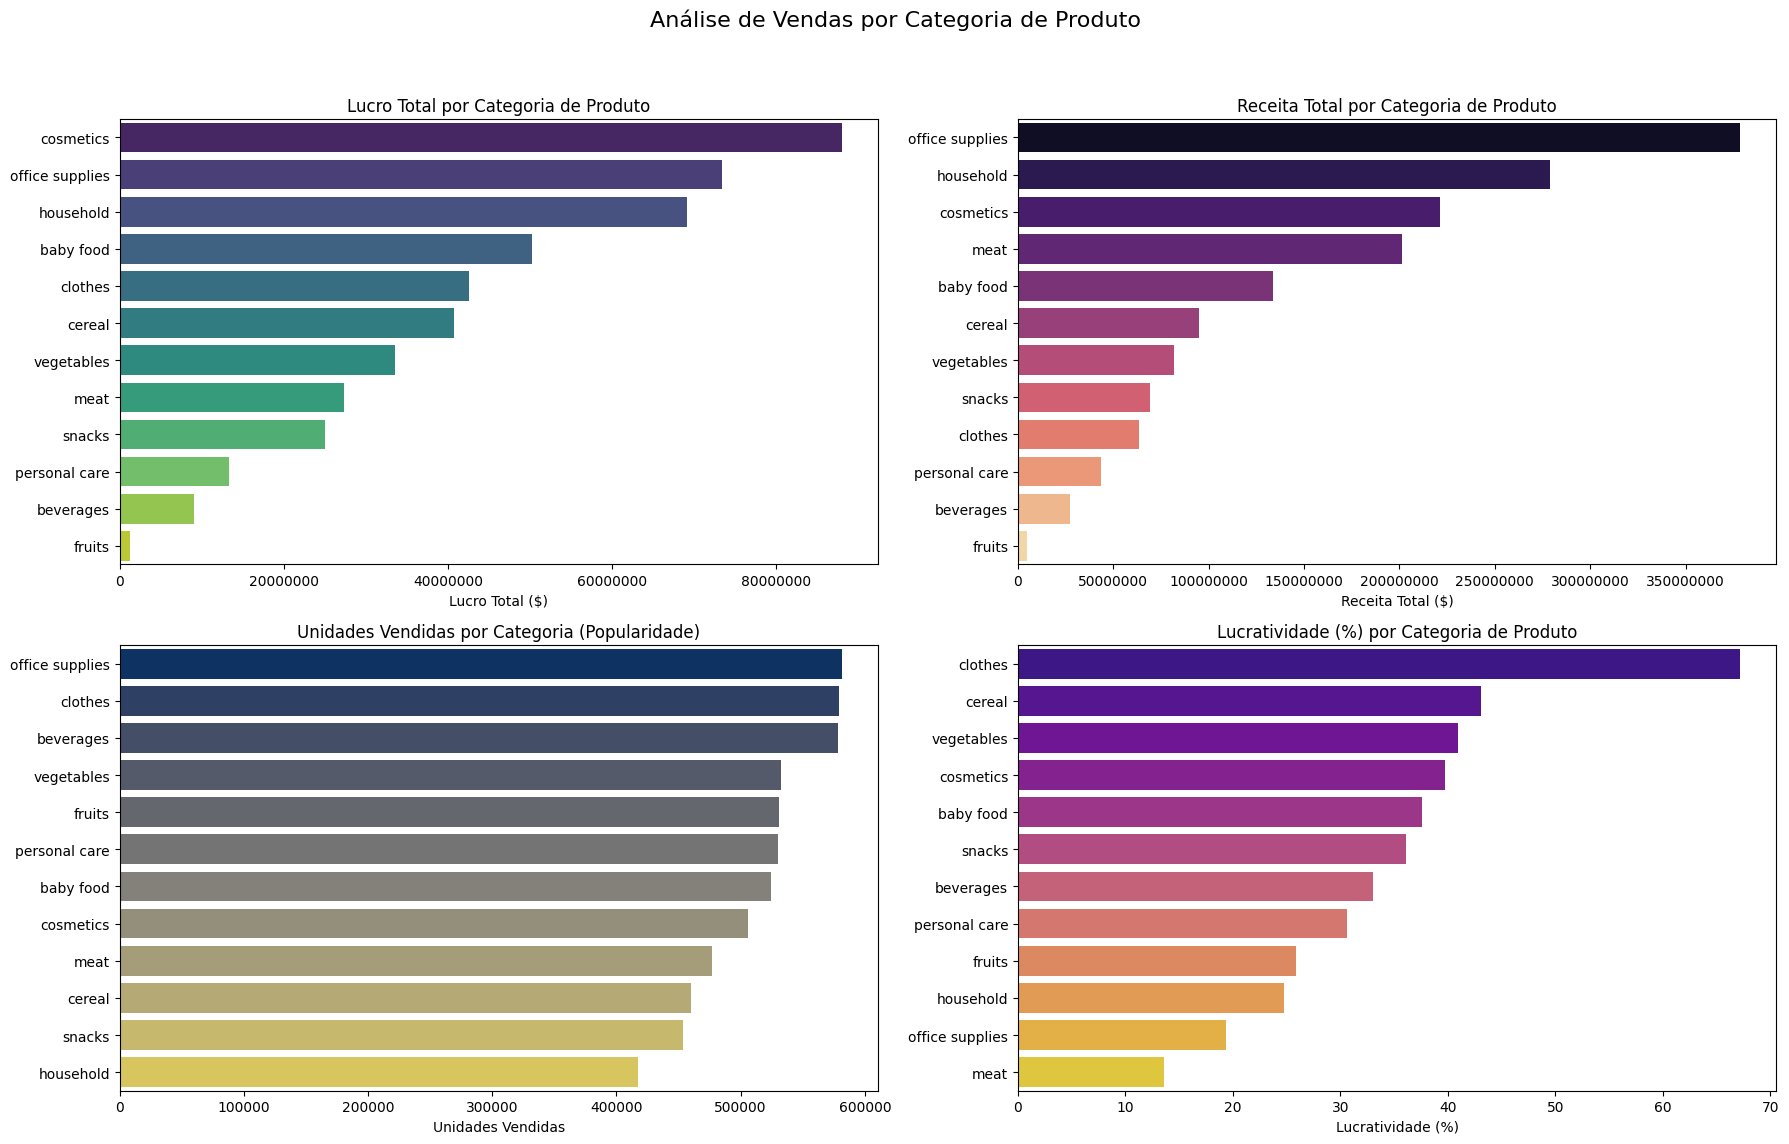

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análise de Vendas por Categoria de Produto', fontsize=16)

# Total de Lucro por Categoria
sns.barplot(ax=axes[0, 0], x='Total_Lucro', y='Categoria do Produto', data=analise_categoria.sort_values('Total_Lucro', ascending=False), palette='viridis')
axes[0, 0].set_title('Lucro Total por Categoria de Produto')
axes[0, 0].set_xlabel('Lucro Total ($)')
axes[0, 0].set_ylabel('')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Total de Receita por Categoria
sns.barplot(ax=axes[0, 1], x='Total_Receita', y='Categoria do Produto', data=analise_categoria.sort_values('Total_Receita', ascending=False), palette='magma')
axes[0, 1].set_title('Receita Total por Categoria de Produto')
axes[0, 1].set_xlabel('Receita Total ($)')
axes[0, 1].set_ylabel('')
axes[0, 1].ticklabel_format(style='plain', axis='x')

# Unidades Vendidas por Categoria (Popularidade)
sns.barplot(ax=axes[1, 0], x='Unidades_Vendidas', y='Categoria do Produto', data=analise_categoria.sort_values('Unidades_Vendidas', ascending=False), palette='cividis')
axes[1, 0].set_title('Unidades Vendidas por Categoria (Popularidade)')
axes[1, 0].set_xlabel('Unidades Vendidas')
axes[1, 0].set_ylabel('')
axes[1, 0].ticklabel_format(style='plain', axis='x')

# Lucratividade (Lucro/Receita) por Categoria
analise_categoria['Lucratividade'] = (analise_categoria['Total_Lucro'] / analise_categoria['Total_Receita']) * 100
sns.barplot(ax=axes[1, 1], x='Lucratividade', y='Categoria do Produto', data=analise_categoria.sort_values('Lucratividade', ascending=False), palette='plasma')
axes[1, 1].set_title('Lucratividade (%) por Categoria de Produto')
axes[1, 1].set_xlabel('Lucratividade (%)')
axes[1, 1].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Análise por País
analise_pais = df_full.groupby('País').agg(
    Total_Receita=('Receita', 'sum'),
    Total_Despesa=('Despesa', 'sum'),
    Total_Lucro=('Lucro Total', 'sum'),
    Unidades_Vendidas=('Unidades Vendidas', 'sum')
).reset_index()

display(analise_pais.sort_values(by='Total_Lucro', ascending=False).head(10))

# Análise por Região
analise_regiao = df_full.groupby('Região').agg(
    Total_Receita=('Receita', 'sum'),
    Total_Despesa=('Despesa', 'sum'),
    Total_Lucro=('Lucro Total', 'sum'),
    Unidades_Vendidas=('Unidades Vendidas', 'sum')
).reset_index()

display(analise_regiao.sort_values(by='Total_Lucro', ascending=False))

,País,Total_Receita,Total_Despesa,Total_Lucro,Unidades_Vendidas
1,andorra,47756693.17,32346656.54,15410036.63,185686.0
43,ukraine,53252317.54,38447391.80,14804925.74,164577.0
27,malta,47145320.81,32535192.93,14610127.88,173641.0
36,san marino,47883708.48,34090715.67,13792992.81,192228.0
18,hungary,42408249.12,28622018.09,13786231.03,152242.0
26,macedonia,49222085.25,35537985.30,13684099.95,203078.0
10,czech republic,53543932.14,39908338.36,13635593.78,142446.0
35,russia,46051659.81,32783977.17,13267682.64,165954.0
6,bosnia and herzegovina,50117508.49,36859905.72,13257602.77,153545.0
17,greece,38699541.70,26375091.57,12324450.13,176859.0


,Região,Total_Receita,Total_Despesa,Total_Lucro,Unidades_Vendidas
1,europe,1.505653e+09,1.057096e+09,4.485568e+08,5761244.0
0,asia,9.333089e+07,6.817863e+07,2.515225e+07,410427.0


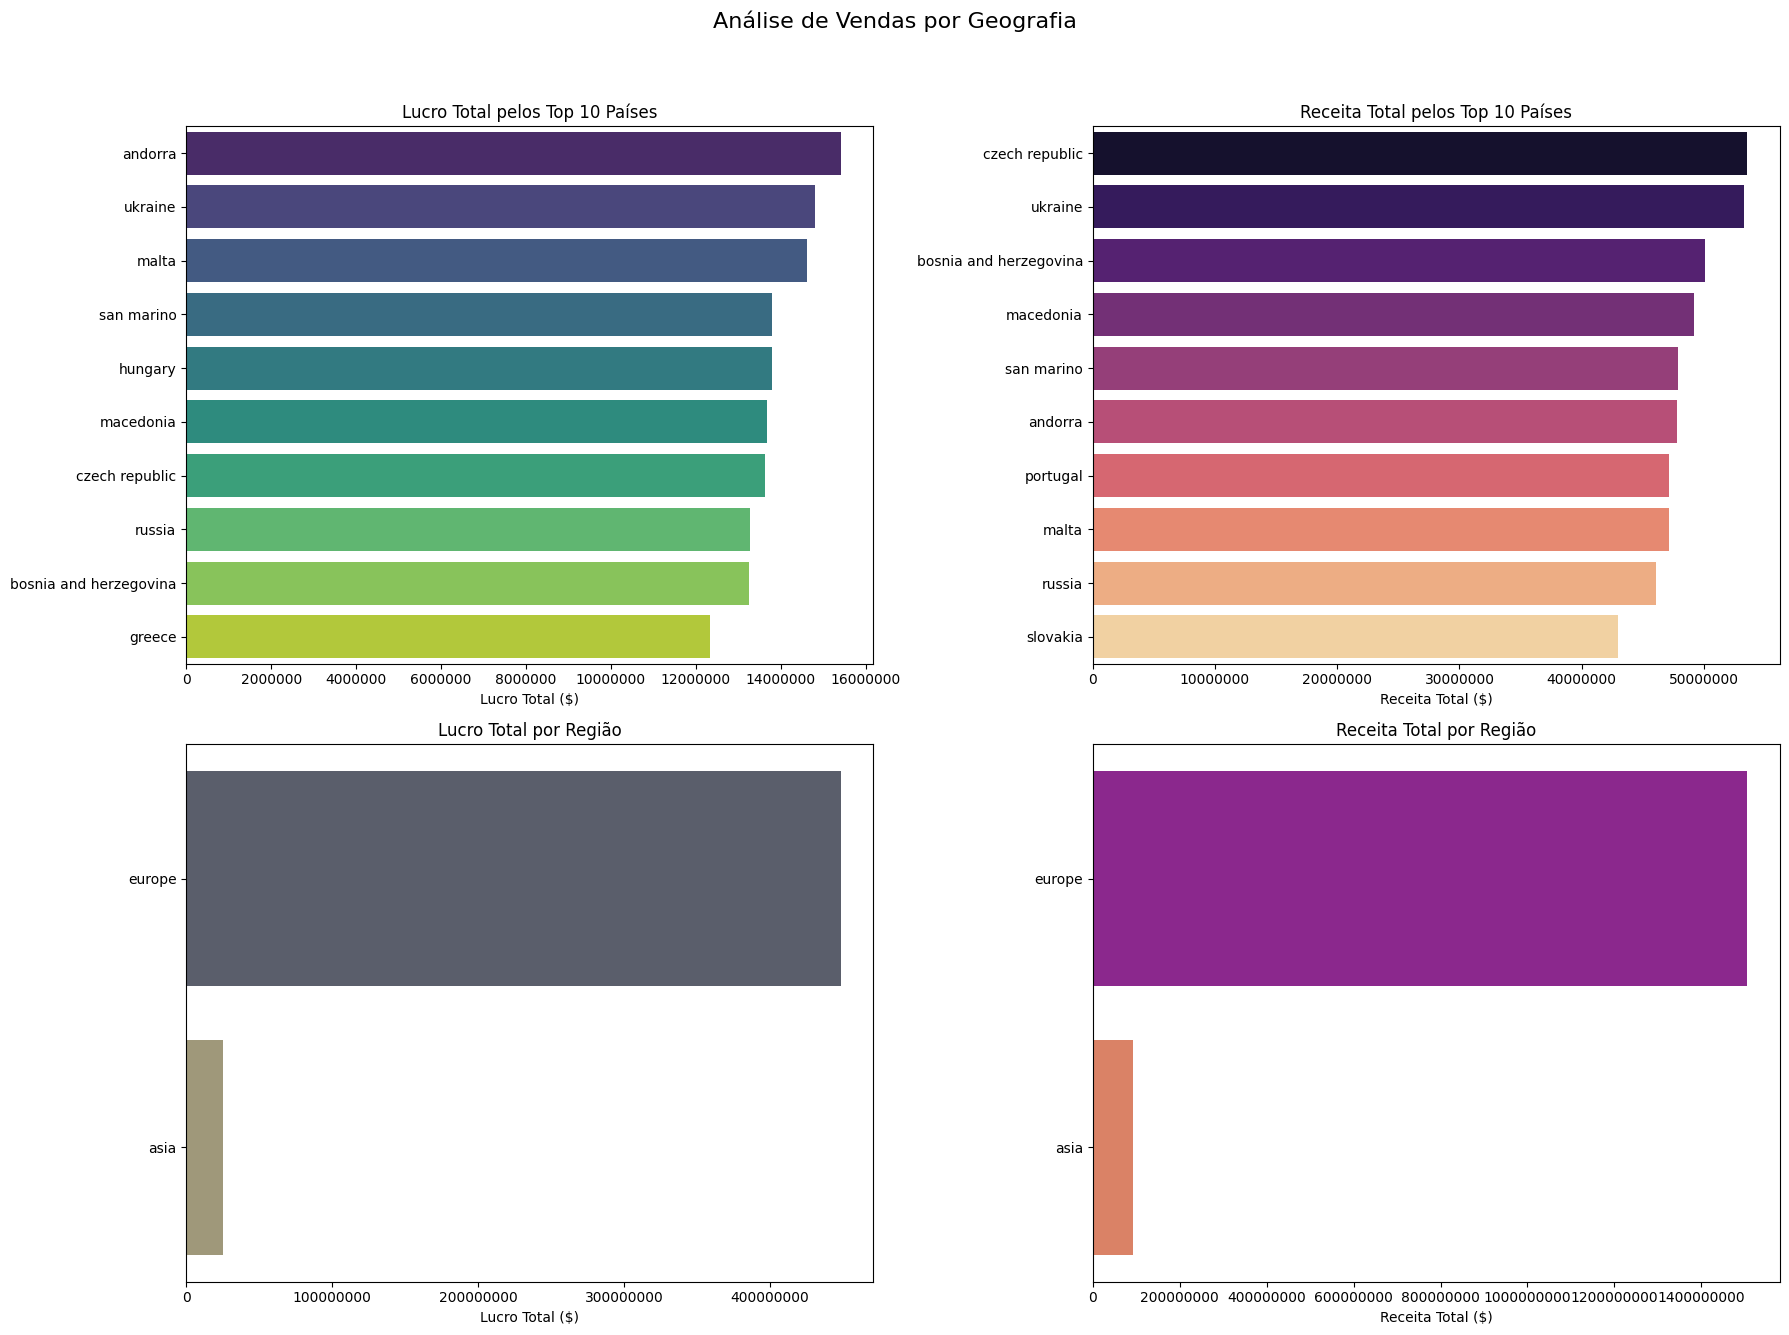

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Análise de Vendas por Geografia', fontsize=16)

# Lucro Total pelos Top 10 Países
sns.barplot(ax=axes[0, 0], x='Total_Lucro', y='País', data=analise_pais.sort_values('Total_Lucro', ascending=False).head(10), palette='viridis', hue='País', legend=False)
axes[0, 0].set_title('Lucro Total pelos Top 10 Países')
axes[0, 0].set_xlabel('Lucro Total ($)')
axes[0, 0].set_ylabel('')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Receita Total pelos Top 10 Países
sns.barplot(ax=axes[0, 1], x='Total_Receita', y='País', data=analise_pais.sort_values('Total_Receita', ascending=False).head(10), palette='magma', hue='País', legend=False)
axes[0, 1].set_title('Receita Total pelos Top 10 Países')
axes[0, 1].set_xlabel('Receita Total ($)')
axes[0, 1].set_ylabel('')
axes[0, 1].ticklabel_format(style='plain', axis='x')

# Lucro Total por Região
sns.barplot(ax=axes[1, 0], x='Total_Lucro', y='Região', data=analise_regiao.sort_values('Total_Lucro', ascending=False), palette='cividis', hue='Região', legend=False)
axes[1, 0].set_title('Lucro Total por Região')
axes[1, 0].set_xlabel('Lucro Total ($)')
axes[1, 0].set_ylabel('')
axes[1, 0].ticklabel_format(style='plain', axis='x')

# Receita Total por Região
sns.barplot(ax=axes[1, 1], x='Total_Receita', y='Região', data=analise_regiao.sort_values('Total_Receita', ascending=False), palette='plasma', hue='Região', legend=False)
axes[1, 1].set_title('Receita Total por Região')
axes[1, 1].set_xlabel('Receita Total ($)')
axes[1, 1].set_ylabel('')
axes[1, 1].ticklabel_format(style='plain', axis='x')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Análise por Canal de Vendas
analise_canal = df_full.groupby('Canal de Vendas').agg(
    Total_Receita=('Receita', 'sum'),
    Total_Despesa=('Despesa', 'sum'),
    Total_Lucro=('Lucro Total', 'sum'),
    Unidades_Vendidas=('Unidades Vendidas', 'sum')
).reset_index()

display(analise_canal.sort_values(by='Total_Lucro', ascending=False))

,Canal de Vendas,Total_Receita,Total_Despesa,Total_Lucro,Unidades_Vendidas
0,offline,8.100305e+08,5.715191e+08,2.385113e+08,3113412.0
1,online,7.889533e+08,5.537556e+08,2.351977e+08,3058259.0


In [ ]:
# Calculo do tempo de envio em dias
df_full['Tempo de Envio (Dias)'] = (df_full['Data de Envio'] - df_full['Data do Pedido']).dt.days

print("Primeiras 5 linhas do DataFrame `df_full` com a nova coluna 'Tempo de Envio (Dias)':")
display(df_full[['Data do Pedido', 'Data de Envio', 'Tempo de Envio (Dias)']].head())

print("Estatísticas descritivas para 'Tempo de Envio (Dias)':")
display(df_full['Tempo de Envio (Dias)'].describe())

Primeiras 5 linhas do DataFrame `df_full` com a nova coluna 'Tempo de Envio (Dias)':


,Data do Pedido,Data de Envio,Tempo de Envio (Dias)
0,2014-10-08,2014-10-18,10
1,2016-08-11,2016-08-11,0
2,2017-05-13,2017-06-13,31
3,2012-08-11,2012-09-18,38
4,2015-03-15,2015-04-18,34


Estatísticas descritivas para 'Tempo de Envio (Dias)':


,Tempo de Envio (Dias)
count,1246.000000
mean,24.875602
std,14.622855
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


### 6.1 Tempo de Envio por Categoria de Produto

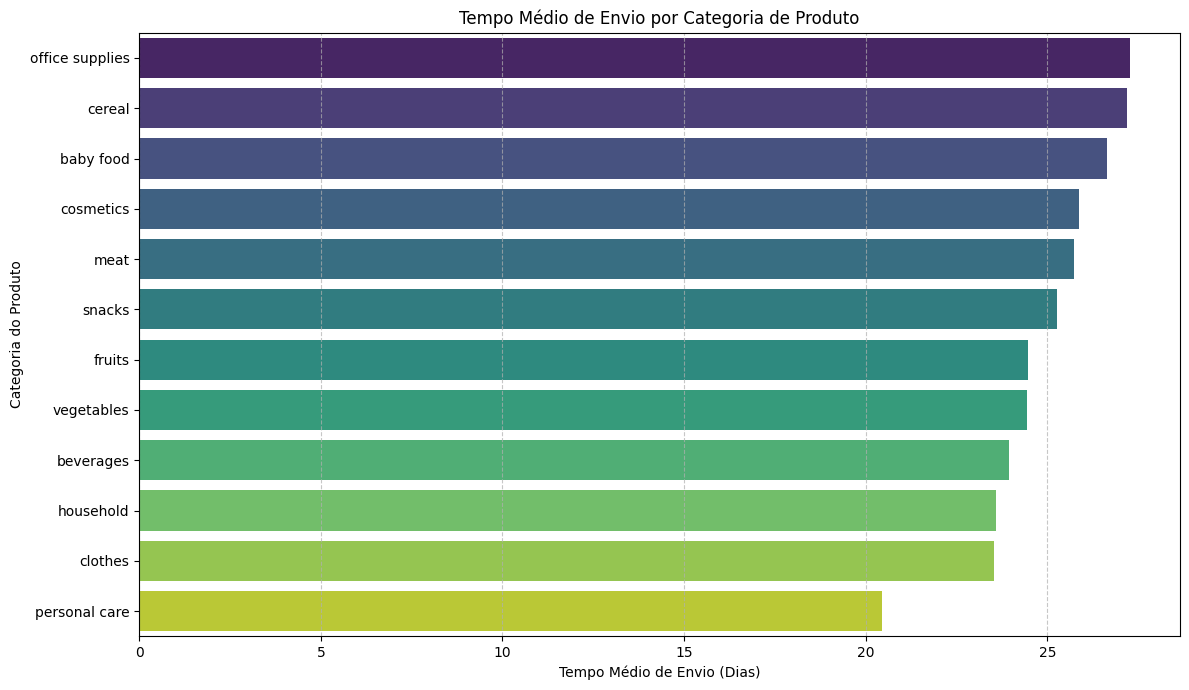

In [ ]:
# Agrupando por Categoria do Produto para calcular o tempo médio de envio
tempo_envio_categoria = df_full.groupby('Categoria do Produto')['Tempo de Envio (Dias)'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Tempo de Envio (Dias)', y='Categoria do Produto', data=tempo_envio_categoria.sort_values('Tempo de Envio (Dias)', ascending=False), palette='viridis', hue='Categoria do Produto', legend=False)
plt.title('Tempo Médio de Envio por Categoria de Produto')
plt.xlabel('Tempo Médio de Envio (Dias)')
plt.ylabel('Categoria do Produto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 6.2 Tempo de Envio por País

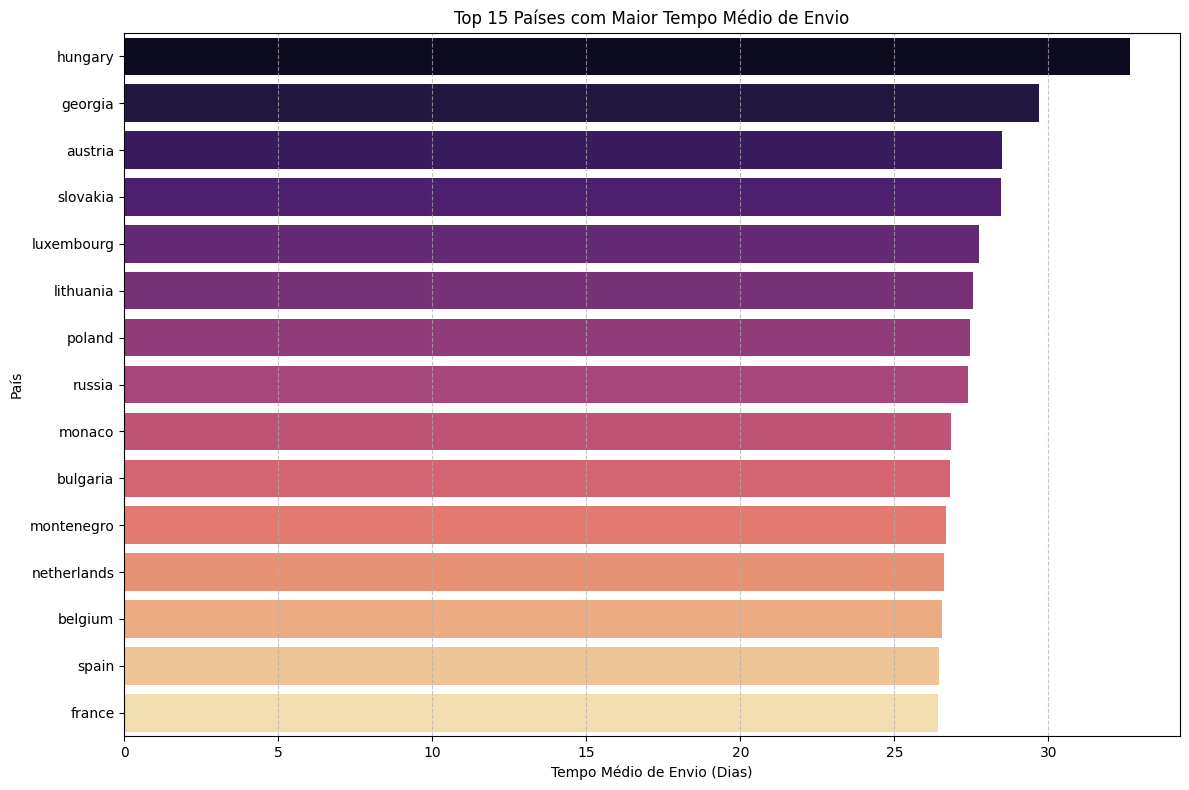

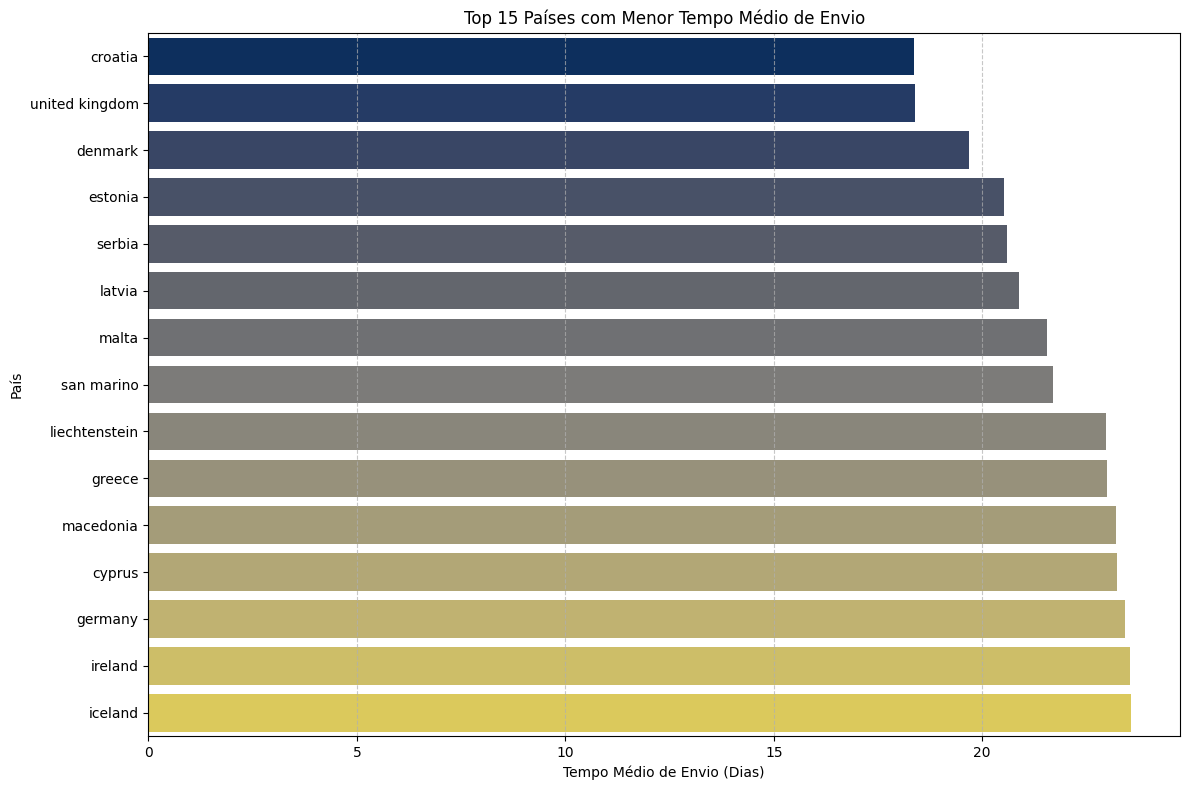

In [ ]:
# Agrupando por País para calcular o tempo médio de envio
tempo_envio_pais = df_full.groupby('País')['Tempo de Envio (Dias)'].mean().reset_index()

# top 15 países com maior tempo médio de envio
plt.figure(figsize=(12, 8))
sns.barplot(x='Tempo de Envio (Dias)', y='País', data=tempo_envio_pais.sort_values('Tempo de Envio (Dias)', ascending=False).head(15), palette='magma', hue='País', legend=False)
plt.title('Top 15 Países com Maior Tempo Médio de Envio')
plt.xlabel('Tempo Médio de Envio (Dias)')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# top 15 países com menor tempo médio de envio
plt.figure(figsize=(12, 8))
sns.barplot(x='Tempo de Envio (Dias)', y='País', data=tempo_envio_pais.sort_values('Tempo de Envio (Dias)', ascending=True).head(15), palette='cividis', hue='País', legend=False)
plt.title('Top 15 Países com Menor Tempo Médio de Envio')
plt.xlabel('Tempo Médio de Envio (Dias)')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 6.3 Tempo de Envio por Região

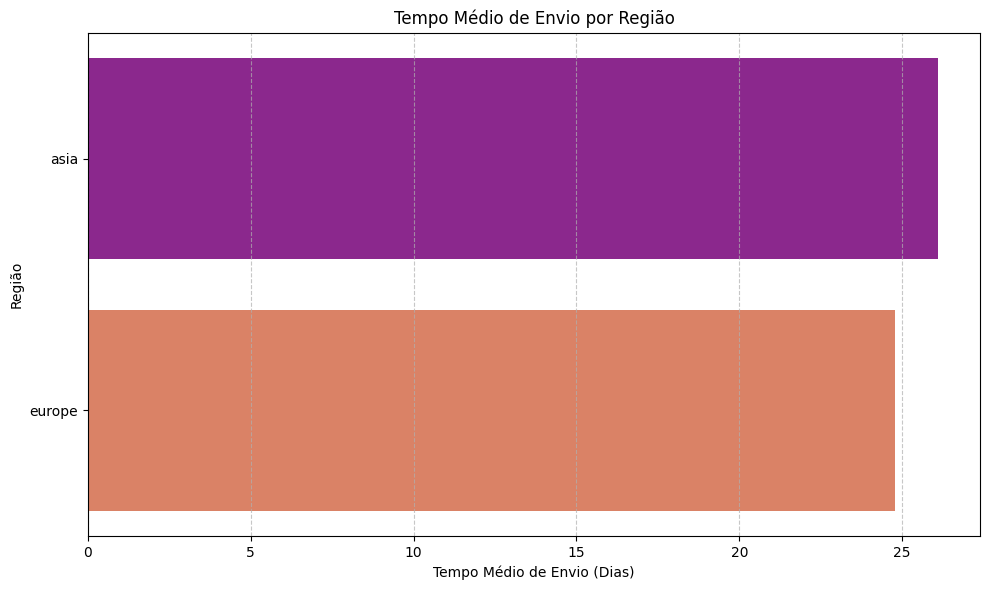

In [ ]:
# Agrupando por Região para calcular o tempo médio de envio
tempo_envio_regiao = df_full.groupby('Região')['Tempo de Envio (Dias)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Tempo de Envio (Dias)', y='Região', data=tempo_envio_regiao.sort_values('Tempo de Envio (Dias)', ascending=False), palette='plasma', hue='Região', legend=False)
plt.title('Tempo Médio de Envio por Região')
plt.xlabel('Tempo Médio de Envio (Dias)')
plt.ylabel('Região')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

,Categoria do Produto,Lucro_Total,Tempo_Medio_Envio
4,cosmetics,88010907.56,25.879630
8,office supplies,73411976.25,27.283186
6,household,69160454.84,23.571429
0,baby food,50256042.90,26.647619
3,clothes,42544746.72,23.539216
2,cereal,40774964.94,27.198020
11,vegetables,33617356.30,24.438095
7,meat,27297727.60,25.735294
10,snacks,25012661.94,25.263158
9,personal care,13290821.60,20.444444


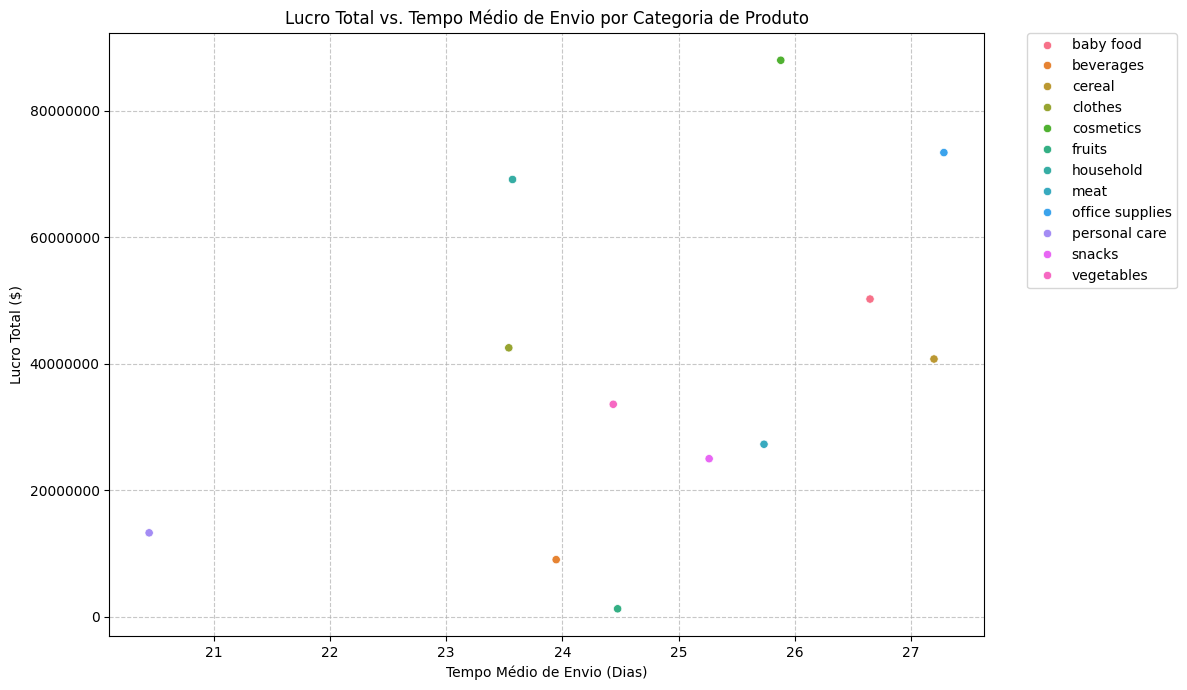

In [ ]:
# Agregando Lucro Total e Tempo Médio de Envio por Categoria do Produto
analise_lucro_tempo_categoria = df_full.groupby('Categoria do Produto').agg(
    Lucro_Total=('Lucro Total', 'sum'),
    Tempo_Medio_Envio=('Tempo de Envio (Dias)', 'mean')
).reset_index()

display(analise_lucro_tempo_categoria.sort_values(by='Lucro_Total', ascending=False))

plt.figure(figsize=(12, 7))
sns.scatterplot(x='Tempo_Medio_Envio', y='Lucro_Total', hue='Categoria do Produto', data=analise_lucro_tempo_categoria)
plt.title('Lucro Total vs. Tempo Médio de Envio por Categoria de Produto')
plt.xlabel('Tempo Médio de Envio (Dias)')
plt.ylabel('Lucro Total ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### 7.2 Relação Lucro vs. Tempo de Envio por País

,País,Lucro_Total,Tempo_Medio_Envio
1,andorra,15410036.63,26.275000
43,ukraine,14804925.74,25.757576
27,malta,14610127.88,21.562500
36,san marino,13792992.81,21.700000
18,hungary,13786231.03,32.640000
26,macedonia,13684099.95,23.218750
10,czech republic,13635593.78,25.225806
35,russia,13267682.64,27.375000
6,bosnia and herzegovina,13257602.77,26.060606
17,greece,12324450.13,23.000000


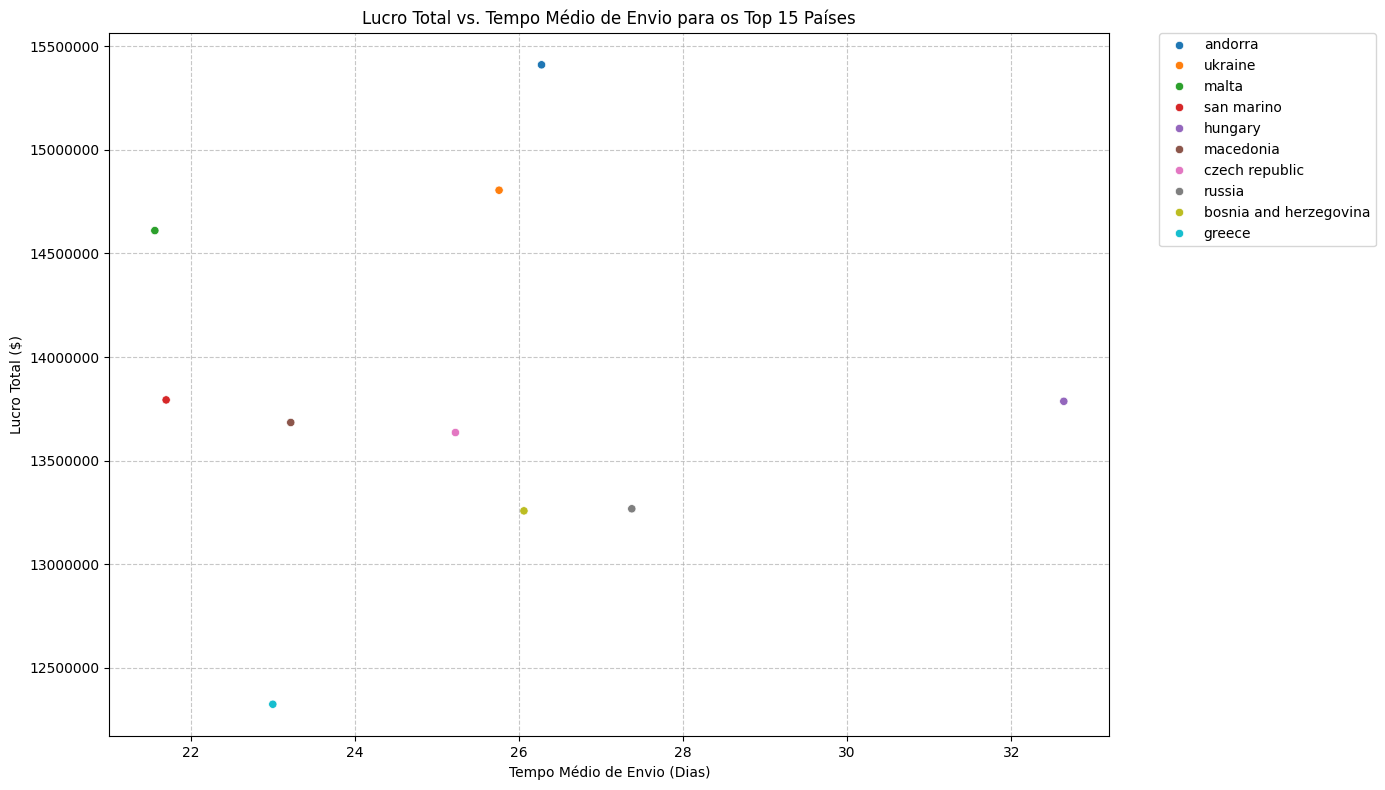

In [ ]:
# Agregando Lucro Total e Tempo Médio de Envio por País
analise_lucro_tempo_pais = df_full.groupby('País').agg(
    Lucro_Total=('Lucro Total', 'sum'),
    Tempo_Medio_Envio=('Tempo de Envio (Dias)', 'mean')
).reset_index()

# top 10 países na tabela
display(analise_lucro_tempo_pais.sort_values(by='Lucro_Total', ascending=False).head(10))

top_10_paises_lucro = analise_lucro_tempo_pais.sort_values(by='Lucro_Total', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.scatterplot(x='Tempo_Medio_Envio', y='Lucro_Total', hue='País', data=top_10_paises_lucro)
plt.title('Lucro Total vs. Tempo Médio de Envio para os Top 15 Países')
plt.xlabel('Tempo Médio de Envio (Dias)')
plt.ylabel('Lucro Total ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### 7.3 Relação Lucro vs. Tempo de Envio por Região

,Região,Lucro_Total,Tempo_Medio_Envio
1,europe,4.485568e+08,24.790378
0,asia,2.515225e+07,26.085366


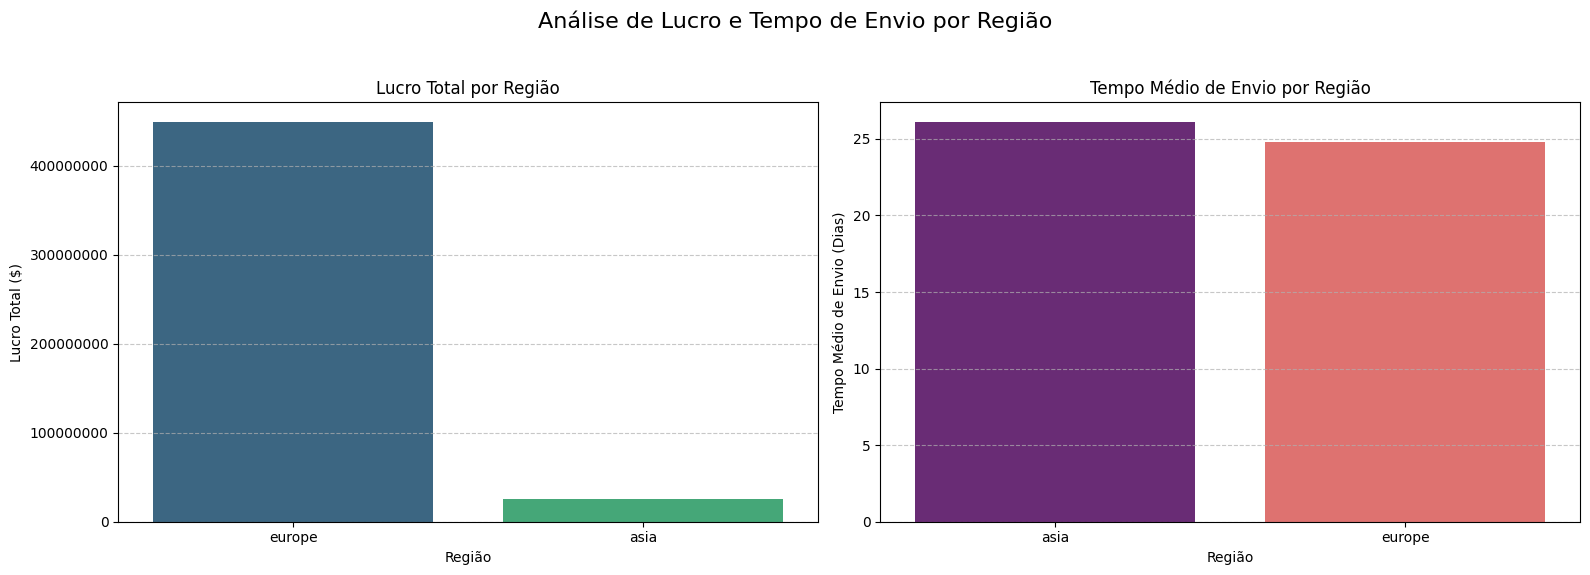

In [ ]:
# Agregando Lucro Total e Tempo Médio de Envio por Região
analise_lucro_tempo_regiao = df_full.groupby('Região').agg(
    Lucro_Total=('Lucro Total', 'sum'),
    Tempo_Medio_Envio=('Tempo de Envio (Dias)', 'mean')
).reset_index()

display(analise_lucro_tempo_regiao.sort_values(by='Lucro_Total', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise de Lucro e Tempo de Envio por Região', fontsize=16)

# Lucro Total por Região
sns.barplot(ax=axes[0], x='Região', y='Lucro_Total', data=analise_lucro_tempo_regiao.sort_values('Lucro_Total', ascending=False), palette='viridis', hue='Região', legend=False)
axes[0].set_title('Lucro Total por Região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Lucro Total ($)')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Tempo Médio de Envio por Região
sns.barplot(ax=axes[1], x='Região', y='Tempo_Medio_Envio', data=analise_lucro_tempo_regiao.sort_values('Tempo_Medio_Envio', ascending=False), palette='magma', hue='Região', legend=False)
axes[1].set_title('Tempo Médio de Envio por Região')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Tempo Médio de Envio (Dias)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

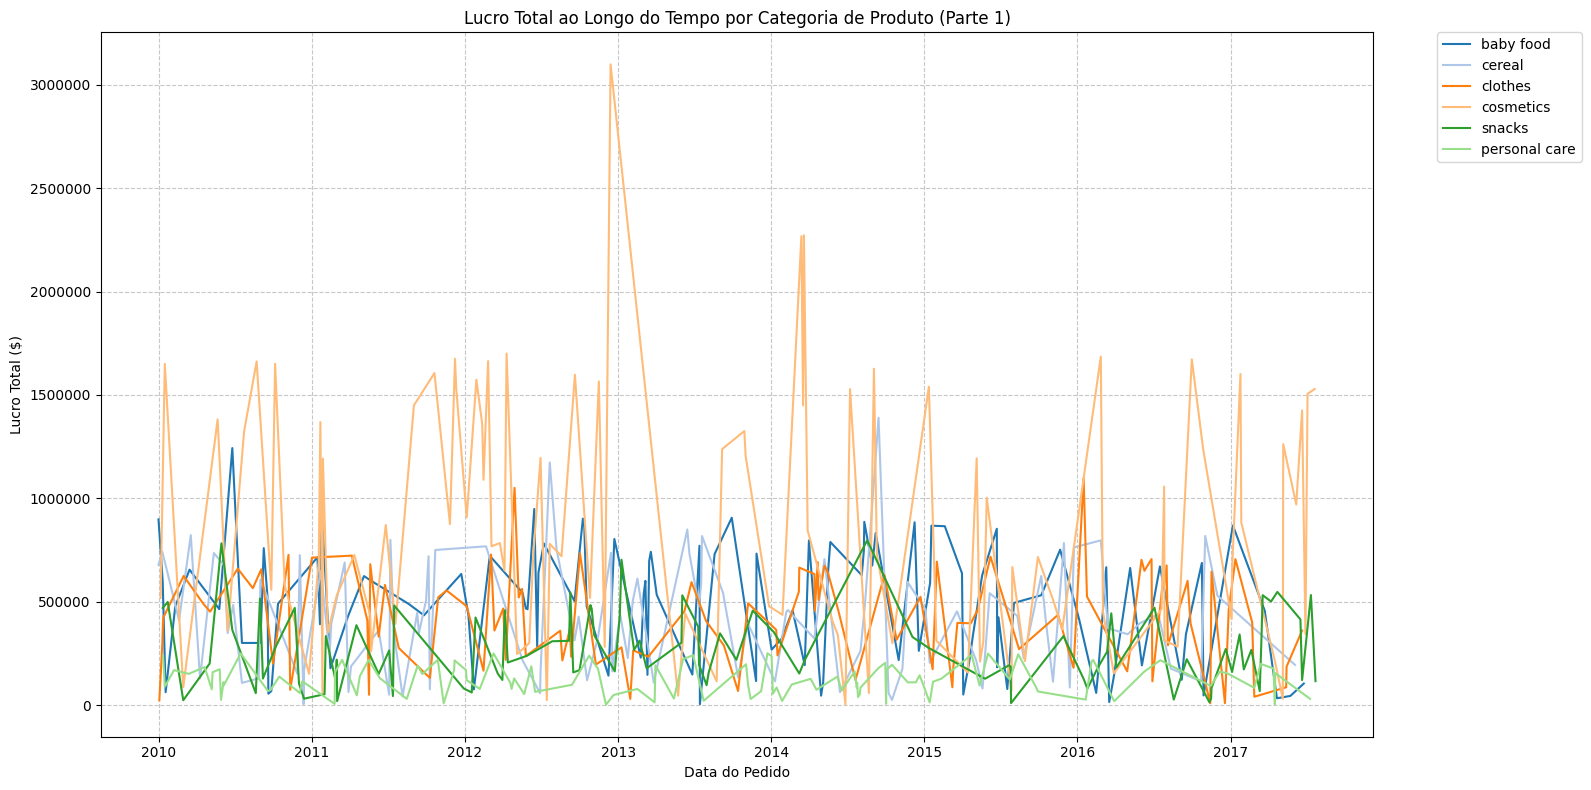

In [ ]:

# Agrupando por data e categoria de produto para ver a evolução do lucro ao longo do tempo
profit_time_category = df_full.groupby(['Data do Pedido', 'Categoria do Produto'])['Lucro Total'].sum().reset_index()

# Obter categorias de produtos únicas
all_categories = profit_time_category['Categoria do Produto'].unique()

# Dividir as categorias em duas metades
half_point = len(all_categories) // 2
categories_group1 = all_categories[:half_point]
categories_group2 = all_categories[half_point:]

# Filtrar o DataFrame para o primeiro grupo de categorias
profit_time_category_g1 = profit_time_category[profit_time_category['Categoria do Produto'].isin(categories_group1)]

plt.figure(figsize=(16, 8))
sns.lineplot(x='Data do Pedido', y='Lucro Total', hue='Categoria do Produto', data=profit_time_category_g1, palette='tab20')
plt.title('Lucro Total ao Longo do Tempo por Categoria de Produto (Parte 1)')
plt.xlabel('Data do Pedido')
plt.ylabel('Lucro Total ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

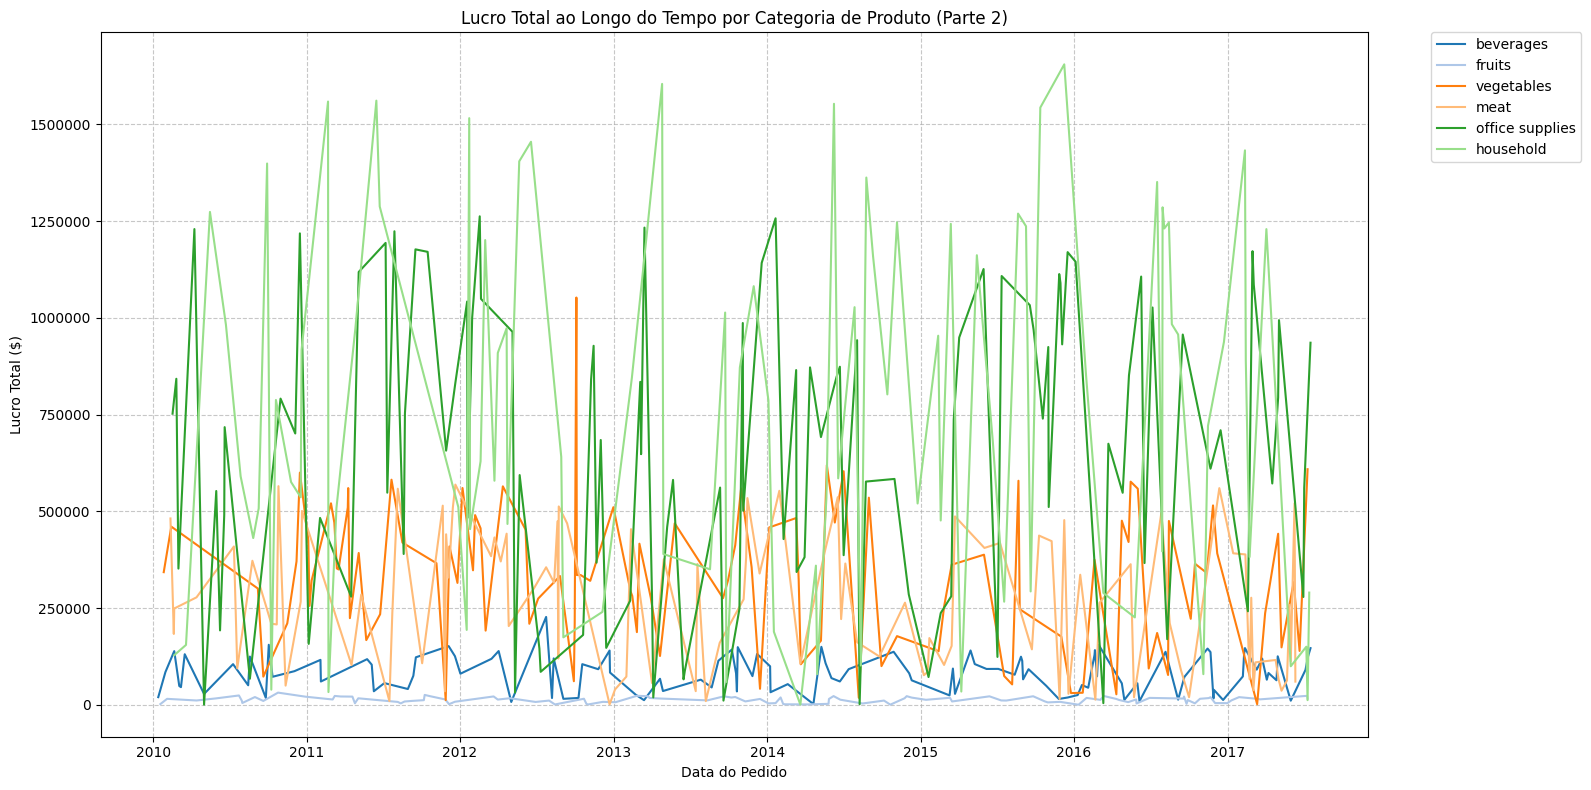

In [ ]:

# Filtrando o DataFrame para o segundo grupo de categorias
profit_time_category_g2 = profit_time_category[profit_time_category['Categoria do Produto'].isin(categories_group2)]

plt.figure(figsize=(16, 8))
sns.lineplot(x='Data do Pedido', y='Lucro Total', hue='Categoria do Produto', data=profit_time_category_g2, palette='tab20')
plt.title('Lucro Total ao Longo do Tempo por Categoria de Produto (Parte 2)')
plt.xlabel('Data do Pedido')
plt.ylabel('Lucro Total ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

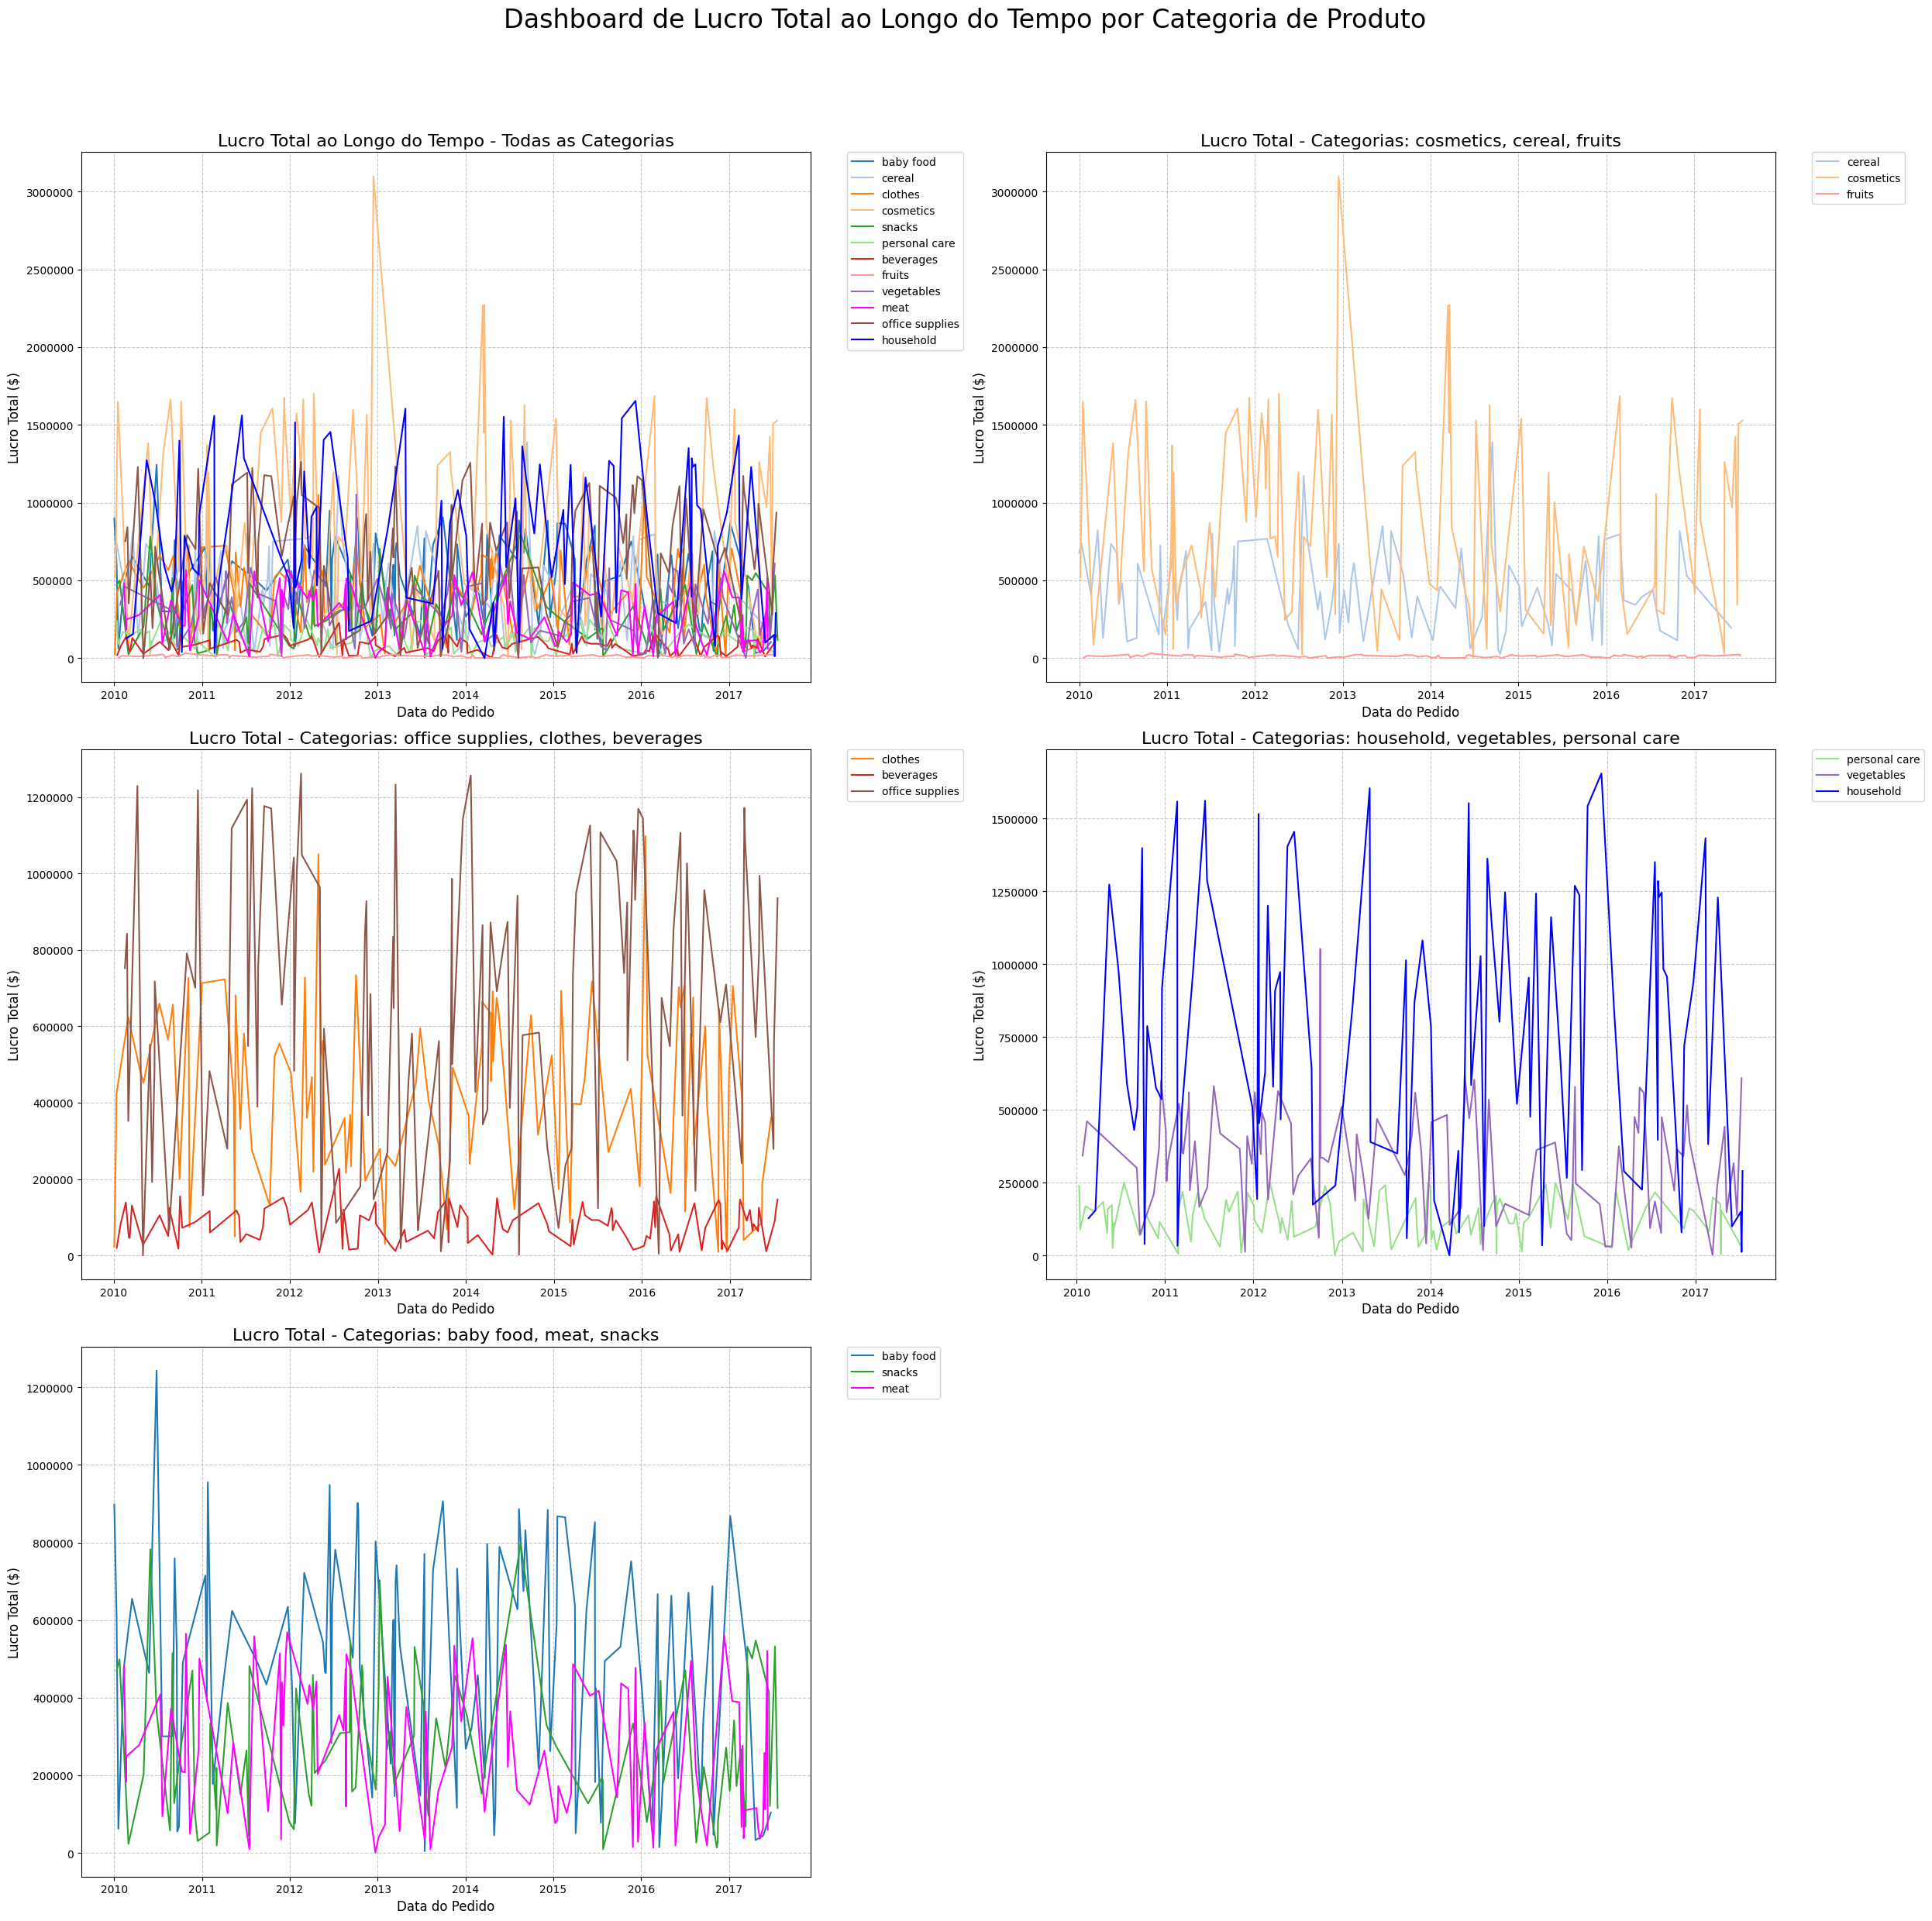

In [ ]:

sorted_categories_by_profit = analise_categoria.sort_values(by='Total_Lucro', ascending=False)['Categoria do Produto'].tolist()

# Obter todas as categorias de produtos únicas
all_categories = profit_time_category['Categoria do Produto'].unique()

category_colors = dict(zip(all_categories, sns.color_palette('tab20', n_colors=len(all_categories))))

if 'household' in category_colors:
    category_colors['household'] = '#0000FF'
if 'meat' in category_colors:
    category_colors['meat'] = '#FF00FF'

categories_group1 = [sorted_categories_by_profit[0], sorted_categories_by_profit[5], sorted_categories_by_profit[11]] # cosmetics (alto), cereal (médio), fruits (baixo)
categories_group2 = [sorted_categories_by_profit[1], sorted_categories_by_profit[4], sorted_categories_by_profit[10]]  # office supplies (alto), clothes (médio), beverages (baixo)
categories_group3 = [sorted_categories_by_profit[2], sorted_categories_by_profit[6], sorted_categories_by_profit[9]]  # household (alto), vegetables (médio), personal care (baixo)
categories_group4 = [sorted_categories_by_profit[3], sorted_categories_by_profit[7], sorted_categories_by_profit[8]]  # baby food (alto), meat (médio), snacks (médio)

fig, axes = plt.subplots(3, 2, figsize=(25, 25))
fig.suptitle('Dashboard de Lucro Total ao Longo do Tempo por Categoria de Produto', fontsize=24, y=1.02)

# Gráfico 1: Todas as Categorias
sns.lineplot(ax=axes[0, 0], x='Data do Pedido', y='Lucro Total', hue='Categoria do Produto', data=profit_time_category, palette=category_colors)
axes[0, 0].set_title('Lucro Total ao Longo do Tempo - Todas as Categorias', fontsize=16)
axes[0, 0].set_xlabel('Data do Pedido', fontsize=12)
axes[0, 0].set_ylabel('Lucro Total ($)', fontsize=12)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

# Gráfico 2: Grupo 1 de Categorias
profit_time_category_g1 = profit_time_category[profit_time_category['Categoria do Produto'].isin(categories_group1)]
sns.lineplot(ax=axes[0, 1], x='Data do Pedido', y='Lucro Total', hue='Categoria do Produto', data=profit_time_category_g1, palette=category_colors)
axes[0, 1].set_title(f'Lucro Total - Categorias: {', '.join(categories_group1)}', fontsize=16)
axes[0, 1].set_xlabel('Data do Pedido', fontsize=12)
axes[0, 1].set_ylabel('Lucro Total ($)', fontsize=12)
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 1].ticklabel_format(style='plain', axis='y')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

# Gráfico 3: Grupo 2 de Categorias
profit_time_category_g2 = profit_time_category[profit_time_category['Categoria do Produto'].isin(categories_group2)]
sns.lineplot(ax=axes[1, 0], x='Data do Pedido', y='Lucro Total', hue='Categoria do Produto', data=profit_time_category_g2, palette=category_colors)
axes[1, 0].set_title(f'Lucro Total - Categorias: {', '.join(categories_group2)}', fontsize=16)
axes[1, 0].set_xlabel('Data do Pedido', fontsize=12)
axes[1, 0].set_ylabel('Lucro Total ($)', fontsize=12)
axes[1, 0].grid(True, linestyle='--', alpha=0.7)
axes[1, 0].ticklabel_format(style='plain', axis='y')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

# Gráfico 4: Grupo 3 de Categorias
profit_time_category_g3 = profit_time_category[profit_time_category['Categoria do Produto'].isin(categories_group3)]
sns.lineplot(ax=axes[1, 1], x='Data do Pedido', y='Lucro Total', hue='Categoria do Produto', data=profit_time_category_g3, palette=category_colors)
axes[1, 1].set_title(f'Lucro Total - Categorias: {', '.join(categories_group3)}', fontsize=16)
axes[1, 1].set_xlabel('Data do Pedido', fontsize=12)
axes[1, 1].set_ylabel('Lucro Total ($)', fontsize=12)
axes[1, 1].grid(True, linestyle='--', alpha=0.7)
axes[1, 1].ticklabel_format(style='plain', axis='y')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

# Gráfico 5: Grupo 4 de Categorias
profit_time_category_g4 = profit_time_category[profit_time_category['Categoria do Produto'].isin(categories_group4)]
sns.lineplot(ax=axes[2, 0], x='Data do Pedido', y='Lucro Total', hue='Categoria do Produto', data=profit_time_category_g4, palette=category_colors)
axes[2, 0].set_title(f'Lucro Total - Categorias: {', '.join(categories_group4)}', fontsize=16)
axes[2, 0].set_xlabel('Data do Pedido', fontsize=12)
axes[2, 0].set_ylabel('Lucro Total ($)', fontsize=12)
axes[2, 0].grid(True, linestyle='--', alpha=0.7)
axes[2, 0].ticklabel_format(style='plain', axis='y')
axes[2, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

# Ocultar o sexto subplot que não está sendo utilizado
fig.delaxes(axes[2, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

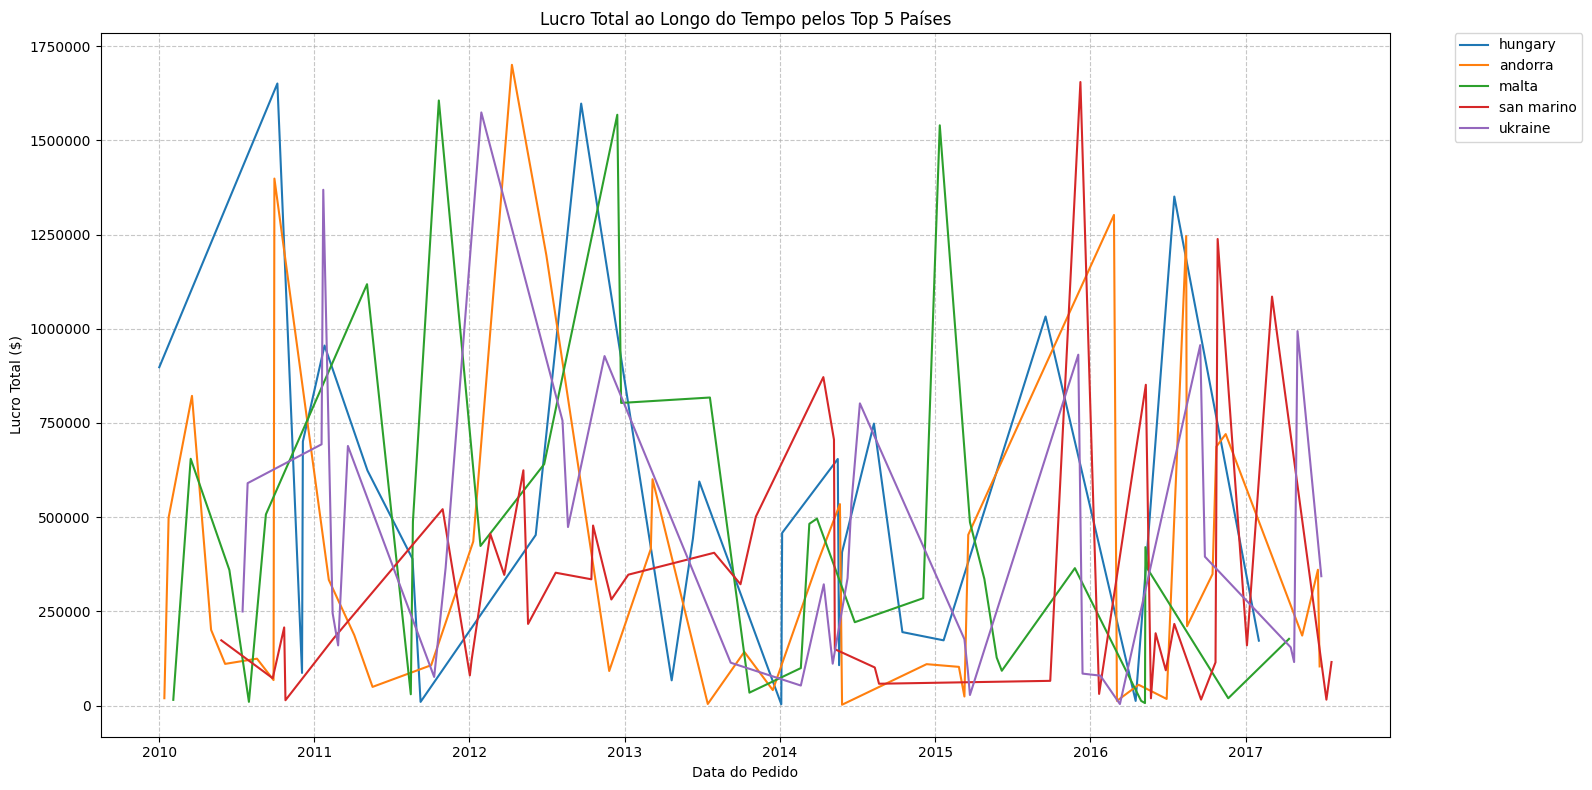

In [ ]:
#  top 5 países com maior lucro total para a análise temporal
top_5_paises = df_full.groupby('País')['Lucro Total'].sum().nlargest(5).index
profit_time_country = df_full[df_full['País'].isin(top_5_paises)].groupby(['Data do Pedido', 'País'])['Lucro Total'].sum().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(x='Data do Pedido', y='Lucro Total', hue='País', data=profit_time_country)
plt.title('Lucro Total ao Longo do Tempo pelos Top 5 Países')
plt.xlabel('Data do Pedido')
plt.ylabel('Lucro Total ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

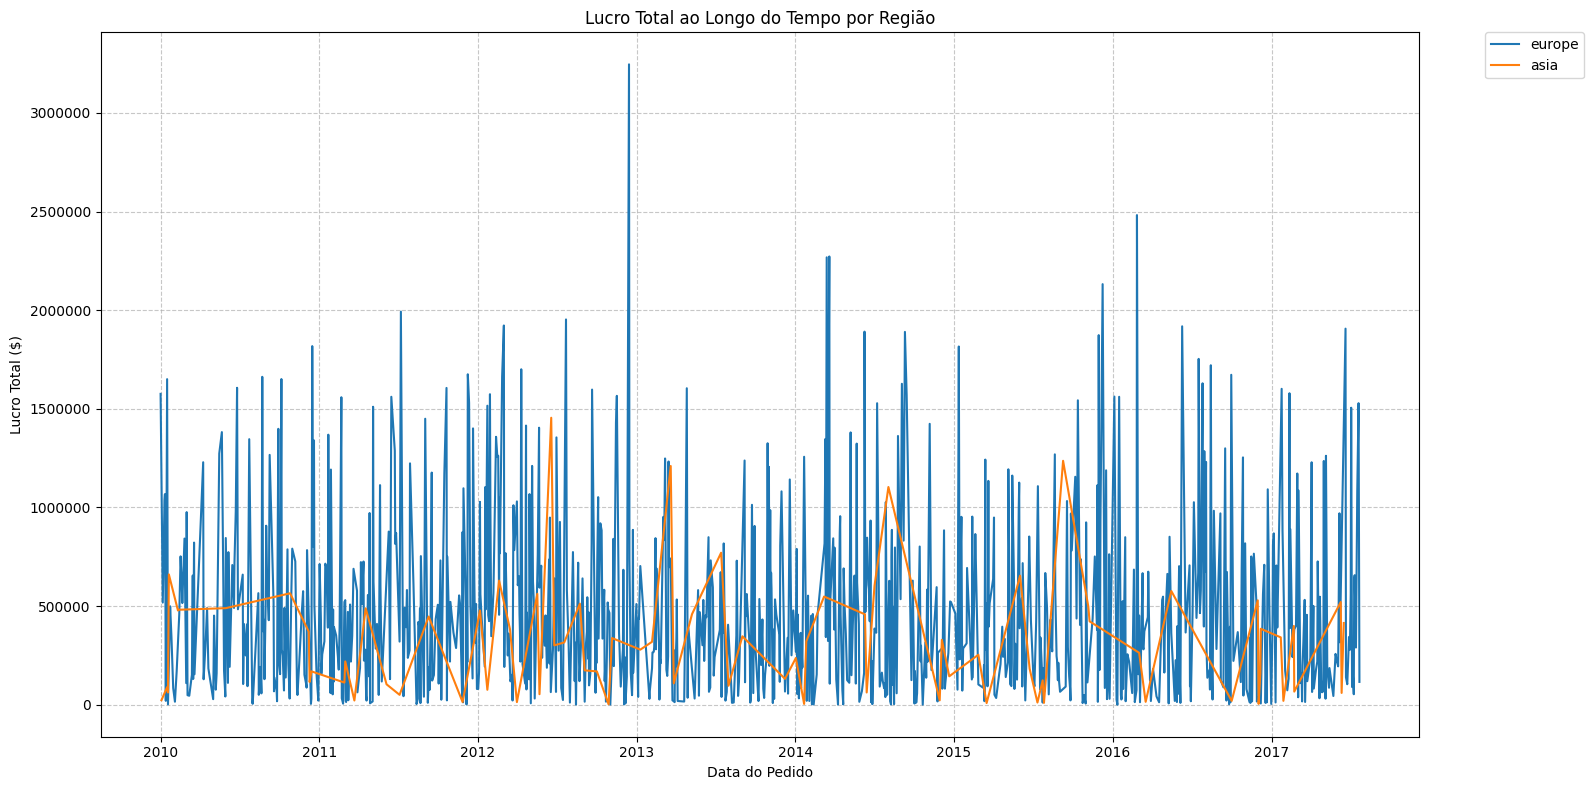

In [ ]:
# Agrupando por data e região para ver a evolução do lucro ao longo do tempo
profit_time_region = df_full.groupby(['Data do Pedido', 'Região'])['Lucro Total'].sum().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(x='Data do Pedido', y='Lucro Total', hue='Região', data=profit_time_region)
plt.title('Lucro Total ao Longo do Tempo por Região')
plt.xlabel('Data do Pedido')
plt.ylabel('Lucro Total ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4571/4260310197.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_sales = sales_by_day_category.pivot_table(index='Categoria do Produto', columns='Day of the Week Name', values='Unidades Vendidas')


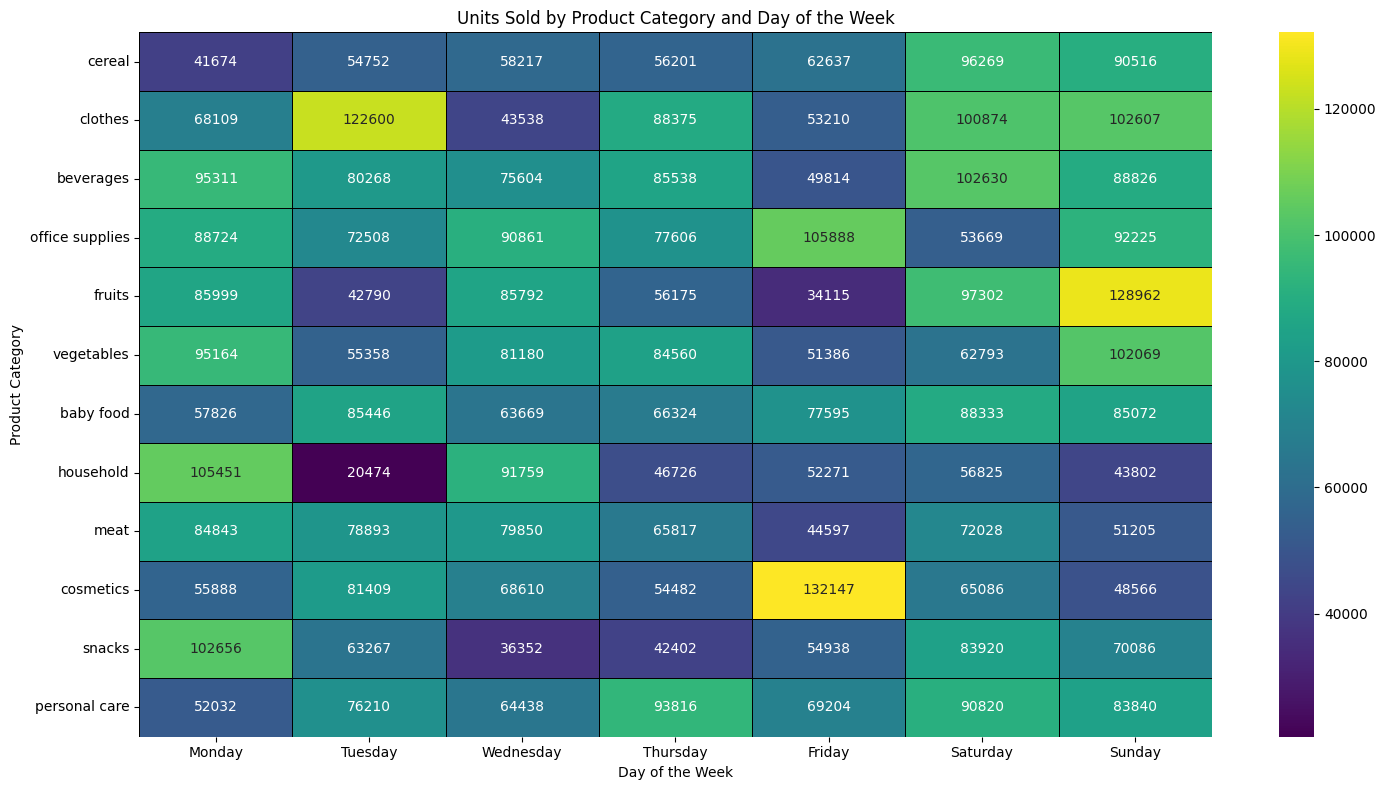

In [ ]:
# Extrair o nome do dia da semana da 'Data do Pedido'
df_full['Day of the Week Name'] = df_full['Data do Pedido'].dt.day_name()

# Obter todas as categorias de produto únicas
all_product_categories = df_full['Categoria do Produto'].unique()

# Definir a ordem correta dos dias da semana para o tipo categórico
day_names_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_full['Day of the Week Name'] = pd.Categorical(df_full['Day of the Week Name'], categories=day_names_ordered, ordered=True)
df_full['Categoria do Produto'] = pd.Categorical(df_full['Categoria do Produto'], categories=all_product_categories, ordered=True)

sales_by_day_category = df_full.groupby(['Day of the Week Name', 'Categoria do Produto'], observed=False)['Unidades Vendidas'].sum().reset_index()

# Criar um pivot table para o heatmap
pivot_sales = sales_by_day_category.pivot_table(index='Categoria do Produto', columns='Day of the Week Name', values='Unidades Vendidas')

# Visualizar as vendas por dia da semana e categoria de produto usando um heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_sales, cmap='viridis', annot=True, fmt='.0f', linewidths=.5, linecolor='black')
plt.title('Units Sold by Product Category and Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

#### Análise de Sazonalidade por Categoria de Produto (Baseada no Mapa de Calor 'Units Sold by Product Category and Day of the Week')

Com base no mapa de calor mostrando 'Units Sold by Product Category and Day of the Week', podemos identificar os seguintes padrões de sazonalidade:

*   **Clothes:** Esta categoria mostra um pico de vendas notável às **Tuesdays** (122.600 unidades), sendo o dia com o maior volume de vendas. As vendas diminuem significativamente às **Wednesdays** (43.538 unidades). Isso pode indicar uma forte demanda ou campanhas promocionais focadas no início da semana para esta categoria.

*   **Cosmetics:** Observamos um grande volume de vendas às **Mondays** (132.147 unidades), que diminui ao longo da semana. Isso sugere que cosméticos são um item de compra popular no início da semana, talvez em preparação para eventos ou o início da semana de trabalho.

*   **Beverages:** Esta categoria apresenta bom desempenho às **Mondays** (95.311 unidades) e às **Fridays** (80.126 unidades), indicando consumo tanto no início da semana quanto em preparação para o fim de semana.

*   **Office Supplies:** As vendas são fortes às **Mondays** (88.724 unidades) e às **Thursdays** (107.869 unidades), mas caem consideravelmente às **Tuesdays** (53.669 unidades). Isso pode estar relacionado a um ciclo de reabastecimento ou uso intensivo de material de escritório em determinados dias da semana.

*   **Meat:** Carnes mostram vendas mais altas às **Tuesdays** (72.028 unidades) e às **Fridays** (65.670 unidades). Tuesdays podem ser um dia comum para compras de carne, e Fridays refletem a preparação para o fim de semana.

No geral, o mapa de calor revela que a maioria das categorias tende a ter um bom desempenho no início da semana (Monday e Tuesday), com algumas categorias mostrando picos adicionais na Thursday ou Friday. Existem flutuações claras que podem ser exploradas para otimizar as vendas, o inventário e as estratégias de marketing para cada categoria de produto.

# Relatório Detalhado de Análise de Vendas e Logística

Este relatório apresenta uma análise aprofundada das operações de vendas e logística, utilizando dados de eventos, produtos e informações geográficas. O objetivo é identificar padrões, avaliar o desempenho e fornecer insights para otimizar estratégias de negócios.



Inicialmente, carregamos três conjuntos de dados: `events` (eventos de vendas), `countries` (informações sobre países) e `products` (detalhes dos produtos). Realizamos as seguintes etapas de pré-processamento para garantir a qualidade dos dados e prepará-los para a análise:

*   **Tratamento de Valores Ausentes:** Linhas com valores ausentes em 'Country Code' e 'Units Sold' no DataFrame `events`, e em 'alpha-2', 'region', 'sub-region' no DataFrame `countries` foram removidas. O DataFrame `products` não apresentou valores ausentes.
*   **Conversão de Tipos de Dados:** As colunas 'Order Date' e 'Ship Date' no DataFrame `events` foram convertidas para o tipo datetime para permitir análises temporais.
*   **Tratamento de Duplicatas:** Verificamos e removemos quaisquer linhas duplicadas em todos os DataFrames.
*   **Padronização de Strings:** Colunas de texto importantes foram padronizadas (removendo espaços extras e convertendo para minúsculas) para evitar inconsistências.
*   **Mesclagem de DataFrames:** Os DataFrames `events`, `products` e `countries` foram mesclados em um único DataFrame (`df_full`) usando as colunas 'Product ID' com 'id' e 'Country Code' com 'alpha-3', respectivamente, para criar uma visão completa dos dados.
*   **Criação de Novas Colunas:** Adicionamos colunas de métricas importantes como 'Lucro Unitário', 'Lucro Total', 'Receita' e 'Despesa'. Também calculamos o 'Tempo de Envio (Dias)' para cada pedido.
*   **Renomeação de Colunas:** Colunas foram renomeadas para facilitar a compreensão e o uso.



As seguintes métricas-chave de desempenho (KPIs) foram calculadas para ter uma visão geral do negócio:





1.   **Número total de pedidos:** 1246

2.   **Lucro total:** $473,709,035.06

3.   **Número total de paises abrangidos:** 45

4.   **Total de unidades vendidas** 6,171,671

5.   **Vendas totais (Receita)**: $1,598,983,761.26   




A análise por categoria de produto  revelou o seguinte:

*   **Lucro e Receita:** As categorias com maior lucro e receita são 'cosmetics', 'office supplies' e 'baby food'.
*   **Unidades Vendidas (Popularidade):** 'baby food', 'office supplies' e 'cosmetics' também lideram em unidades vendidas, indicando sua popularidade.
*   **Lucratividade:** A 'household' se destaca com a maior lucratividade percentual, seguida por 'office supplies' e 'baby food', mostrando que, mesmo que não vendam o maior volume, a margem de lucro por unidade é superior. É importante notar que a categoria 'fruits' apresenta a menor lucratividade.




A análise geográfica destacou:

*   **Top 10 Países:** Países como 'andorra', 'ukraine' e 'malta' lideram em Lucro Total e Receita Total.
*   **Regiões:** 'europe' contribui esmagadoramente com a maior parte do Lucro Total e Receita Total em comparação com 'asia'.
**negrito**

Ambos os canais de vendas, 'online' e 'offline', contribuem significativamente para o lucro e receita totais, com o canal 'offline' tendo uma ligeira vantagem em todas as métricas.

O 'Tempo de Envio (Dias) foi calculado e analisado para entender a eficiência logística.

Conforme o gráfico gerado, 'personal care' tem o menor tempo médio de envio, enquanto 'office supplies' e 'cereal' apresentam os maiores tempos. Isso pode indicar diferentes cadeias de suprimentos ou desafios logísticos para certas categorias.

Os gráficos mostram os top 15 países com maior e menor tempo médio de envio. Países como 'united kingdom' e 'malta' possuem tempos de envio mais curtos, enquanto outros como 'austria' e 'russia' mostram tempos mais longos.

O gráfico indica que 'europe' e 'asia' têm tempos médios de envio relativamente próximos, com 'asia' ligeiramente maior, sugerindo uma consistência global na logística ou desafios semelhantes em ambas as regiões.



O gráfico de dispersão sugere que, para algumas categorias como 'cosmetics' e 'baby food', um alto lucro total pode estar associado a um tempo de envio ligeiramente mais longo, enquanto outras categorias de alto lucro, como 'household', têm um tempo de envio médio. Não há uma correlação linear óbvia, mas sim uma distribuição que merece atenção individual por categoria.

Para os top 10 países, o gráfico de dispersão mostra uma variedade de relações. Alguns países com alto lucro, como 'andorra' e 'ukraine', têm tempos de envio médios, enquanto 'malta' e 'san marino' combinam alto lucro com tempos de envio relativamente baixos. Isso sugere que a eficiência de envio não é o único fator de lucro e pode haver outras variáveis influenciando (como o preço unitário ou o volume de vendas).

Os gráficos de barras mostram que, embora 'europe' domine em lucro total, ambas as regiões têm tempos médios de envio similares. Isso reforça a ideia de que a eficiência logística pode ser otimizada em ambas as regiões, independentemente do volume de lucro gerado.



Os gráficos de linha (especialmente o dashboard consolidado) mostram a evolução do lucro ao longo do tempo para diferentes categorias. Observamos flutuações e picos em diferentes momentos para categorias distintas. Por exemplo, 'baby food' e 'cosmetics' frequentemente apresentam picos de lucro, enquanto outras categorias podem mostrar tendências mais estáveis ou sazonais. O dashboard permite comparar as tendências de lucro de diferentes grupos de categorias simultaneamente.

O gráfico de linha ilustra a evolução do lucro para os top 5 países. Cada país tem seu próprio padrão de vendas ao longo do tempo, com alguns mostrando picos notáveis em certos períodos, o que pode estar relacionado a eventos específicos ou estratégias de marketing localizadas.

O gráfico de linha  mostra que 'europe' mantém uma liderança consistente no lucro total ao longo do tempo, com flutuações mais pronunciadas, enquanto 'asia' apresenta um padrão mais estável e com menor volume de lucro.



O mapa de calor revelam padrões de vendas por categoria de produto ao longo da semana. Algumas categorias mostram picos em dias específicos:

*   **Clothes:** Pico às **Tuesdays** (122.600 unidades).
*   **Cosmetics:** Grande volume às **Mondays** (132.147 unidades).
*   **Beverages:** Bom desempenho às **Mondays** e **Fridays**.
*   **Office Supplies:** Fortes vendas às **Mondays** e **Thursdays**.
*   **Meat:** Vendas mais altas às **Tuesdays** e **Fridays**.

Em geral, a maioria das categorias tem um bom desempenho no início da semana (Monday e Tuesday), com alguns picos adicionais na Thursday ou Friday. Isso indica oportunidades para campanhas de marketing direcionadas e otimização de estoque com base no dia da semana.




Com base na análise detalhada, as seguintes conclusões e recomendações de negócios podem ser formuladas:

1.  **Otimização por Categoria de Produto:**
    *   **Priorizar 'Household' e 'Office Supplies':** Embora 'cosmetics' e 'baby food' gerem maior lucro total, 'household' e 'office supplies' demonstram alta lucratividade. Estratégias para aumentar o volume de vendas dessas categorias, mantendo a margem, seriam muito benéficas.
    *   **Analisar 'Fruits':** Esta categoria apresenta a menor lucratividade. É crucial investigar os custos, preços e a demanda para determinar se é possível aumentar a margem ou se a categoria deve ser reavaliada.

2.  **Estratégias Geográficas:**
    *   **Foco na Europa:** A região 'europe' é a principal impulsionadora de lucro e receita. Manter e fortalecer as estratégias de vendas e marketing nesta região é fundamental.
    *   **Expansão na Ásia:** Embora 'asia' tenha menor contribuição, representa uma oportunidade de crescimento. Investir em análises de mercado mais aprofundadas e estratégias de entrada adaptadas pode desbloquear um potencial significativo.
    *   **Logística por País:** Países com tempos de envio consistentemente mais longos (como 'austria' e 'russia') podem se beneficiar de otimizações logísticas ou parcerias locais para reduzir o tempo de entrega e melhorar a satisfação do cliente.

3.  **Canais de Vendas:**
    *   **Balanceamento Online/Offline:** Ambos os canais contribuem significativamente. É importante continuar investindo em ambos, garantindo uma experiência omnichannel coesa. A ligeira vantagem do canal offline pode indicar uma base de clientes fiel que valoriza a interação física ou um ponto de venda, ou que as estratégias de marketing para o offline são mais eficazes atualmente.

4.  **Eficiência Logística e Tempo de Envio:**
    *   **Monitoramento Contínuo:** O 'Tempo de Envio (Dias)' é uma métrica crítica para a satisfação do cliente. Deve ser monitorado de perto, especialmente para produtos com tempos de envio mais longos.
    *   **Otimização de Rotas e Fornecedores:** Para categorias e países com tempos de envio elevados, revisar as rotas de transporte e a eficiência dos fornecedores pode gerar melhorias significativas.
    *   **Impacto no Lucro:** Embora não haja uma correlação direta simples entre lucro e tempo de envio, a otimização da entrega pode impactar positivamente a reputação da marca e, consequentemente, as vendas futuras. É importante considerar a percepção do cliente.

5.  **Aproveitar Padrões de Sazonalidade (Dia da Semana):**
    *   **Marketing Direcionado:** As flutuações de vendas por dia da semana ('Tuesdays' para 'Clothes', 'Mondays' para 'Cosmetics' e 'Beverages') indicam oportunidades para campanhas de marketing e promoções focadas nesses dias, capitalizando a demanda existente.
    *   **Gestão de Estoque:** Ajustar os níveis de estoque e a capacidade de envio com base nos dias de pico de vendas pode otimizar a cadeia de suprimentos e reduzir custos de armazenamento e de entrega acelerada.
    *   **Planejamento Operacional:** Compreender os dias de maior e menor volume de envio pode ajudar a alocar melhor os recursos da equipe de logística e planejar a manutenção de sistemas, minimizando interrupções durante os períodos de pico.